# Diamonds Dataset: Exploratory Data Analysis (EDA) 📊

In this notebook, we will perform Exploratory Data Analysis (EDA) on the diamonds dataset. This dataset contains information on diamonds such as their shape, weight, clarity, colour, cut, polish, symmetry, fluorescence, measurements and price. Our goal is to gain insights into the dataset and visualize the distributions of various features to understand the relationships between them.

## Importing Libraries 🛠
We will start by importing the necessary libraries that we will be using throughout the notebook.

- `pandas` - for data manipulation and analysis
- `numpy` - for numerical operations
- `matplotlib` - for data visualization
- `seaborn` - for advanced data visualization

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

## Loading Data 📁

Next, we will load the dataset using pandas read_parquet function.

In [2]:
df = pd.read_parquet("./../data/clean_diamonds.br")
df

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
0,1638147,CUSHION,0.549805,SI2,E,EX,EX,VG,N,1378.650024,5.050781,4.351562,2.939453
1,1630155,CUSHION,0.500000,VVS1,FANCY,EX,EX,VG,F,1379.739990,4.601562,4.308594,2.919922
2,1612606,CUSHION,0.509766,VS2,H,EX,EX,VG,N,1380.189941,4.710938,4.351562,2.939453
3,1638140,CUSHION,0.500000,VS2,H,EX,EX,VG,N,1380.609985,4.910156,4.261719,2.880859
4,1536093,CUSHION,0.529785,SI1,D,EX,VG,VG,N,1383.130005,4.699219,4.460938,3.009766
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6332,1751206,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.000000,5.039062,3.179688
6333,1773024,ROUND,0.500000,SI1,E,EX,EX,EX,N,2453.100098,5.031250,5.058594,3.160156
6336,1789435,ROUND,0.500000,VS2,D,VG,EX,VG,N,2453.199951,4.929688,4.960938,3.189453


## Data Exploration 🔎

Let's explore the data by checking the columns and their data types.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5991 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            5991 non-null   object  
 1   Shape         5991 non-null   category
 2   Weight        5991 non-null   float32 
 3   Clarity       5991 non-null   category
 4   Colour        5991 non-null   category
 5   Cut           5991 non-null   category
 6   Polish        5991 non-null   category
 7   Symmetry      5991 non-null   category
 8   Fluorescence  5991 non-null   category
 9   Price         5991 non-null   float32 
 10  Length        5991 non-null   float32 
 11  Width         5991 non-null   float32 
 12  Depth         5991 non-null   float32 
dtypes: category(7), float32(5), object(1)
memory usage: 254.0+ KB


**Insight 💡**

This DataFrame seems to be a collection of diamond data, with features such as weight, clarity, color, cut, fluorescence and measurements of length, width, and depth as well as corresponding prices. The data types are appropriate for the corresponding columns, with most categorical features represented as category and numerical data represented as float32. There do not seem to be any missing values in this DataFrame, as all columns have a non-null count of 5991.

## Univalent analysis for numerical data 📈

Let's start with univalent analysis for numerical data

The first function describe_numerical takes a pandas DataFrame as an input and returns a summary of numerical columns in the DataFrame. The summary includes basic statistics like count, mean, standard deviation, minimum and maximum values, as well as additional information such as variance, skewness, kurtosis, range, interquartile range (IOR), lower and upper bounds, and the number of outliers. The function is useful for quickly getting a comprehensive overview of the numerical data in a DataFrame.

The second function plot_graph_numerical is used to plot three types of univariate plots for a single numerical variable: a box plot, a violin plot, and a histogram with density plot. The function takes a pandas Series object as input and plots the three graphs in one figure. The function is useful for visualizing the distribution, central tendency, spread, and outliers of a single numerical variable. The function also sets up the title, axes labels, and plot dimensions for the figure using the _setup helper function.

In [4]:
def describe_numerical(df):
    stats = df.describe()
    stats.loc['var'] = df.var().tolist()
    stats.loc['skew'] = df.skew().tolist()
    stats.loc['kurtosis'] = df.kurtosis().tolist()
    stats.loc['range'] = stats.loc['max'] - stats.loc['min']
    stats.loc['IOR'] = stats.loc['75%'] - stats.loc['25%']
    stats.loc['lower_bound'] = stats.loc['25%'] - 1.5 * stats.loc['IOR']
    stats.loc['upper_bound'] = stats.loc['75%'] + 1.5 * stats.loc['IOR']
    outliers = (df < stats.loc['lower_bound']) | (df > stats.loc['upper_bound'])
    outliers_count = outliers.sum()
    stats.loc['outliers'] = outliers_count.tolist()
    return stats

In [5]:
def plot_graph_numerical(data):
    f, (ax_box,ax_violin, ax_hist) = plt.subplots(3, sharex=True)

    sns.boxplot(x=data, ax = ax_box, palette='viridis')
    _setup(ax_box, 'Box Plot', data)
    sns.violinplot(x=data, ax = ax_violin, palette='viridis')
    _setup(ax_violin, 'Violin Plot', data)
    sns.histplot(x=data, kde=True, ax = ax_hist, color='#21918c')
    _setup(
        ax_hist, 'Histogram + Density Plot', data
    )
    f.suptitle(f'Univariate Analysis of the {data.name} Variable')

    f.set_figwidth(20)
    f.set_figheight(10)
    plt.tight_layout()
    plt.show()


def _setup(ax, title, data):
    ax.set_title(title)
    ax.set_xlabel(f'{data.name}')
    ax.set_ylabel('Value')

List of numerical columns present in dataset

In [6]:
df.select_dtypes(include=np.number).columns

Index(['Weight', 'Price', 'Length', 'Width', 'Depth'], dtype='object')

Feature Weight

In [7]:
describe_numerical(df.Weight)

count          5991.000000
mean              0.632957
std               0.392322
min               0.180054
25%               0.449951
50%               0.500000
75%               0.750000
max               6.019531
var               0.153917
skew              3.915490
kurtosis         26.995016
range             5.839478
IOR               0.300049
lower_bound      -0.000122
upper_bound       1.200073
outliers        388.000000
Name: Weight, dtype: float64

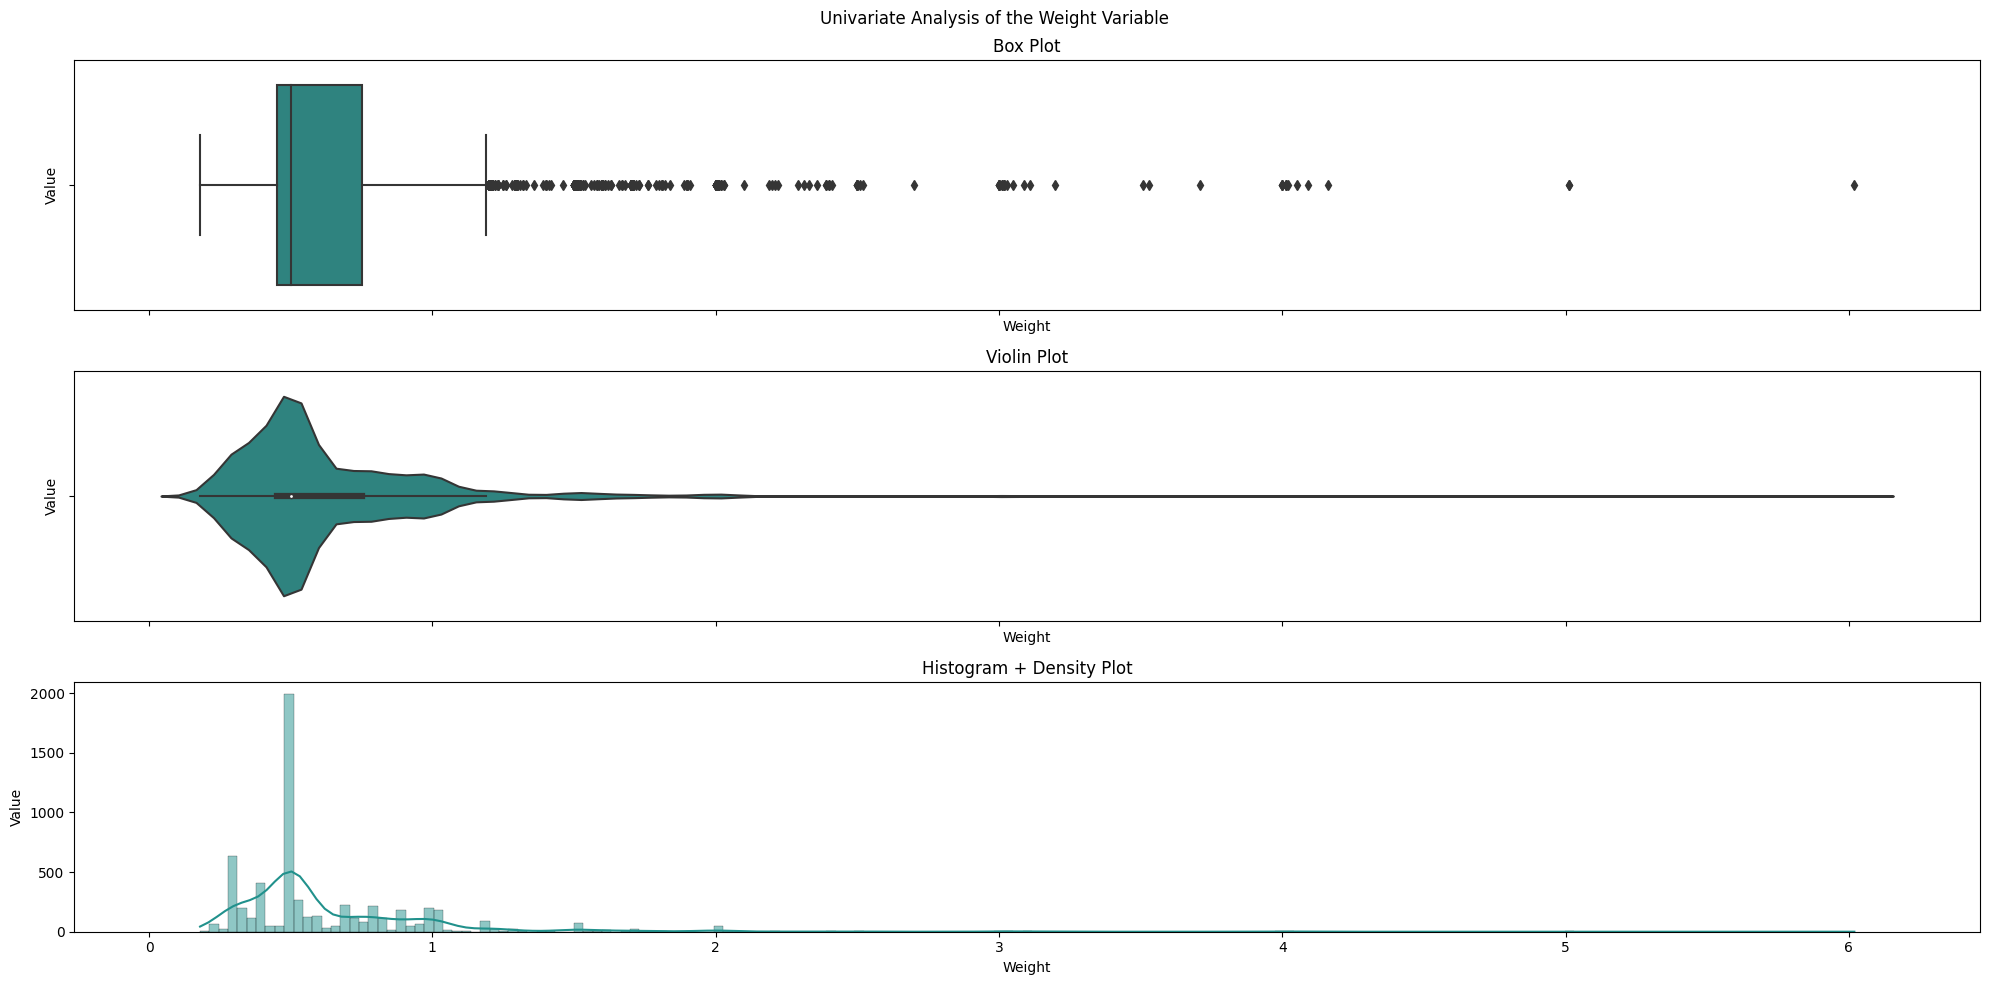

In [8]:
plot_graph_numerical(df.Weight)

**Insight 💡**

- The column has 5991 entries, with a mean of 0.632957 and a standard deviation of 0.392322.
- The minimum weight is 0.180054 and the maximum weight is 6.019531.
- The 25th, 50th (median), and 75th percentiles are 0.449951, 0.5, and 0.75, respectively. The interquartile range (IOR) is the difference between the 75th and 25th percentiles, which is 0.300049 in this case.
- The 'var' row represents the variance of the data, which is 0.153917.
- The 'skew' row represents the skewness of the data, which is 3.915490. This indicates that the distribution of weights is highly skewed to the right.
- The 'kurtosis' row represents the kurtosis of the data, which is 26.995016. This indicates that the distribution is highly leptokurtic or has heavy tails. This means that the variable has a high probability of extreme values (outliers) compared to a normal distribution.
- The 'range' row shows the difference between the maximum and minimum values in the column, which is 5.839478.
- The 'lower_bound' and 'upper_bound' rows show the lower and upper bounds for outliers, respectively, using the interquartile range method.
- The 'outliers' row shows the number of values in the column that are considered outliers based on the lower and upper bounds. In this case, there are 388 outliers.

Feature Price

In [9]:
describe_numerical(df.Price)

count          5.991000e+03
mean           2.482217e+03
std            4.147261e+03
min            6.832200e+02
25%            1.282925e+03
50%            1.870830e+03
75%            2.259220e+03
max            7.614768e+04
var            1.719977e+07
skew           1.042610e+01
kurtosis       1.365686e+02
range          7.546446e+04
IOR            9.762950e+02
lower_bound   -1.815175e+02
upper_bound    3.723662e+03
outliers       5.190000e+02
Name: Price, dtype: float64

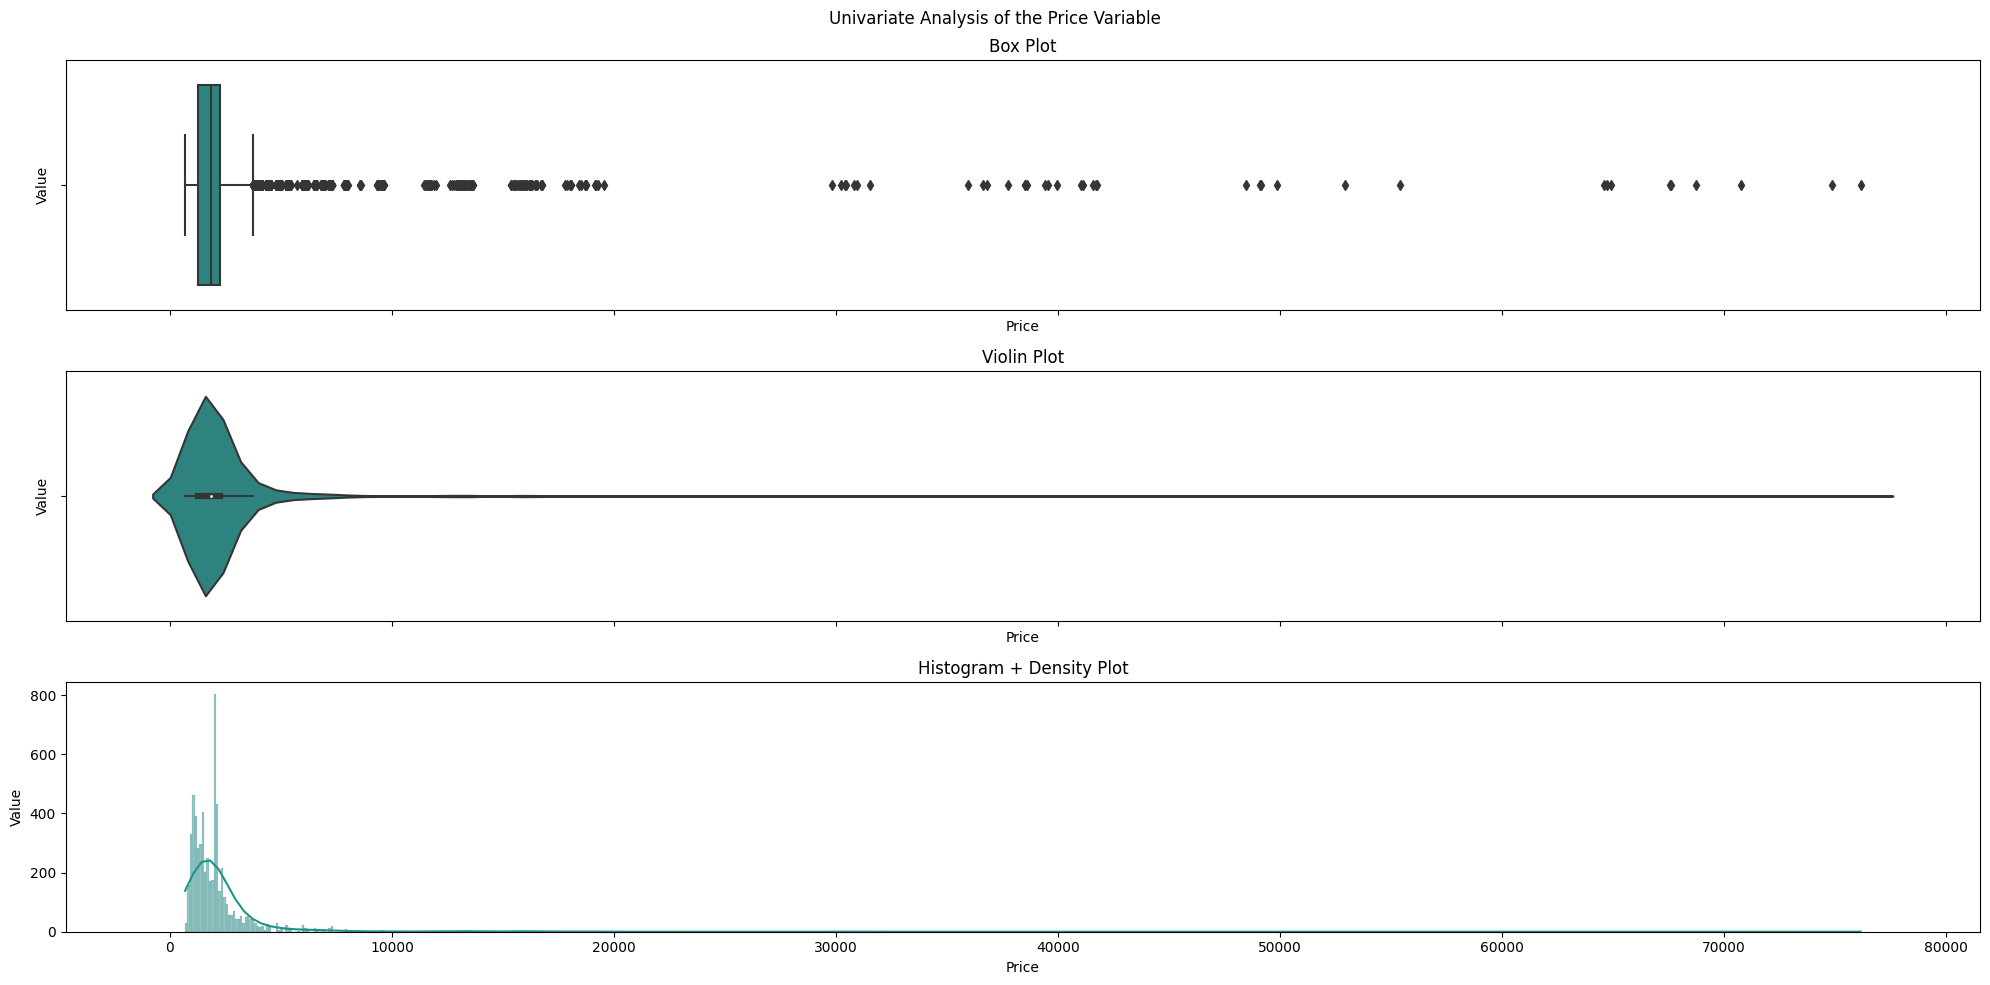

In [10]:
plot_graph_numerical(df.Price)

**Insight 💡**

- The column has 5991 entries, with a mean of 2482.217 and a standard deviation of 4147.261.
- The minimum price is 683.22 and the maximum price is 76147.68.
- The 25th, 50th (median), and 75th percentiles are 1282.925, 1870.830, and 2259.220, respectively. The interquartile range (IOR) is the difference between the 75th and 25th percentiles, which is 976.295 in this case.
- The 'var' row represents the variance of the data, which is 17199767. The variance is a measure of how spread out the data is, with higher values indicating more spread.
- The 'skew' row represents the skewness of the data, which is 10.42610. A positive skewness indicates that the distribution is skewed to the right. In this case, the distribution is highly skewed to the right.
- The 'kurtosis' row represents the kurtosis of the data, which is 136.5686. This indicates that the distribution is highly leptokurtic or has heavy tails. This means that the variable has a high probability of extreme values (outliers) compared to a normal distribution.
- The 'range' row shows the difference between the maximum and minimum values in the column, which is 75464.46.
- The 'lower_bound' and 'upper_bound' rows show the lower and upper bounds for outliers, respectively, using the interquartile range method. The lower bound is -181.5175 and the upper bound is 3723.662.
- The 'outliers' row shows the number of values in the column that are considered outliers based on the lower and upper bounds. In this case, there are 519 outliers.

Feature Length

In [11]:
describe_numerical(df.Length)

count          5991.000000
mean              5.357271
std               1.178498
min               1.000000
25%               4.671875
50%               5.109375
75%               5.871094
max               9.992188
var               1.388857
skew              0.732775
kurtosis          2.737966
range             8.992188
IOR               1.199219
lower_bound       2.873047
upper_bound       7.669922
outliers        359.000000
Name: Length, dtype: float64

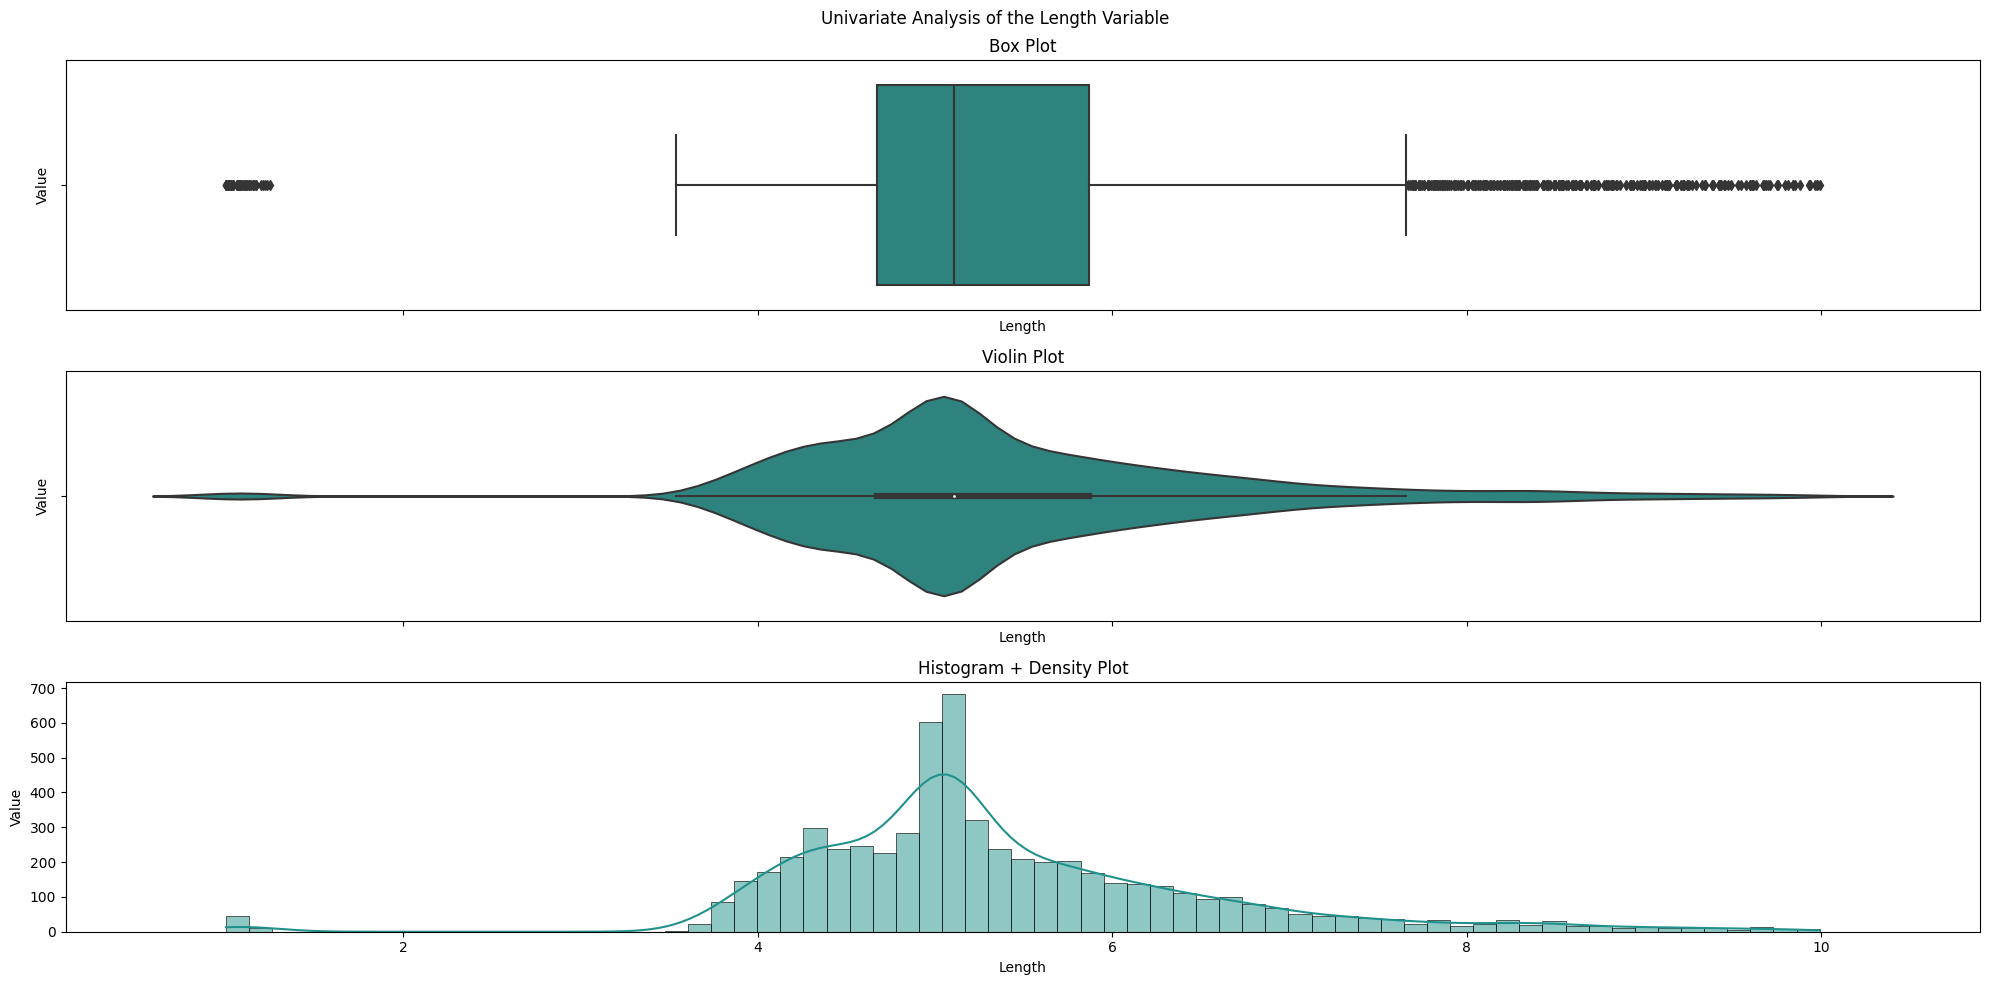

In [12]:
plot_graph_numerical(df.Length)

**Insight 💡**

- The column has 5991 entries, with a mean of 5.357271 and a standard deviation of 1.178498.
- The minimum value in the column is 1.000000 and the maximum value is 9.992188.
- The 25th, 50th (median), and 75th percentiles are 4.671875, 5.109375, and 5.871094, respectively. The interquartile range (IOR) is the difference between the 75th and 25th percentiles, which is 1.199219 in this case.
- The 'var' row represents the variance of the data, which is 1.388857.
- The 'skew' row represents the skewness of the data, which is 0.732775. This indicates that the distribution of values is slightly skewed to the right.
- The 'kurtosis' row represents the kurtosis of the data, which is 2.737966. This indicates that the distribution is platykurtic, which means that it has thinner tails and fewer outliers than a normal distribution.
- The 'range' row shows the difference between the maximum and minimum values in the column, which is 8.992188.
- The 'lower_bound' and 'upper_bound' rows show the lower and upper bounds for outliers, respectively, using the interquartile range method. The lower bound is 2.873047 and the upper bound is 7.669922.
- The 'outliers' row shows the number of values in the column that are considered outliers based on the lower and upper bounds. In this case, there are 359 outliers.

Feature Width

In [13]:
describe_numerical(df.Width)

count          5991.000000
mean              4.771036
std               0.784624
min               0.620117
25%               4.328125
50%               4.851562
75%               5.160156
max               9.851562
var               0.615635
skew              0.569460
kurtosis          4.783453
range             9.231445
IOR               0.832031
lower_bound       3.080078
upper_bound       6.408203
outliers        164.000000
Name: Width, dtype: float64

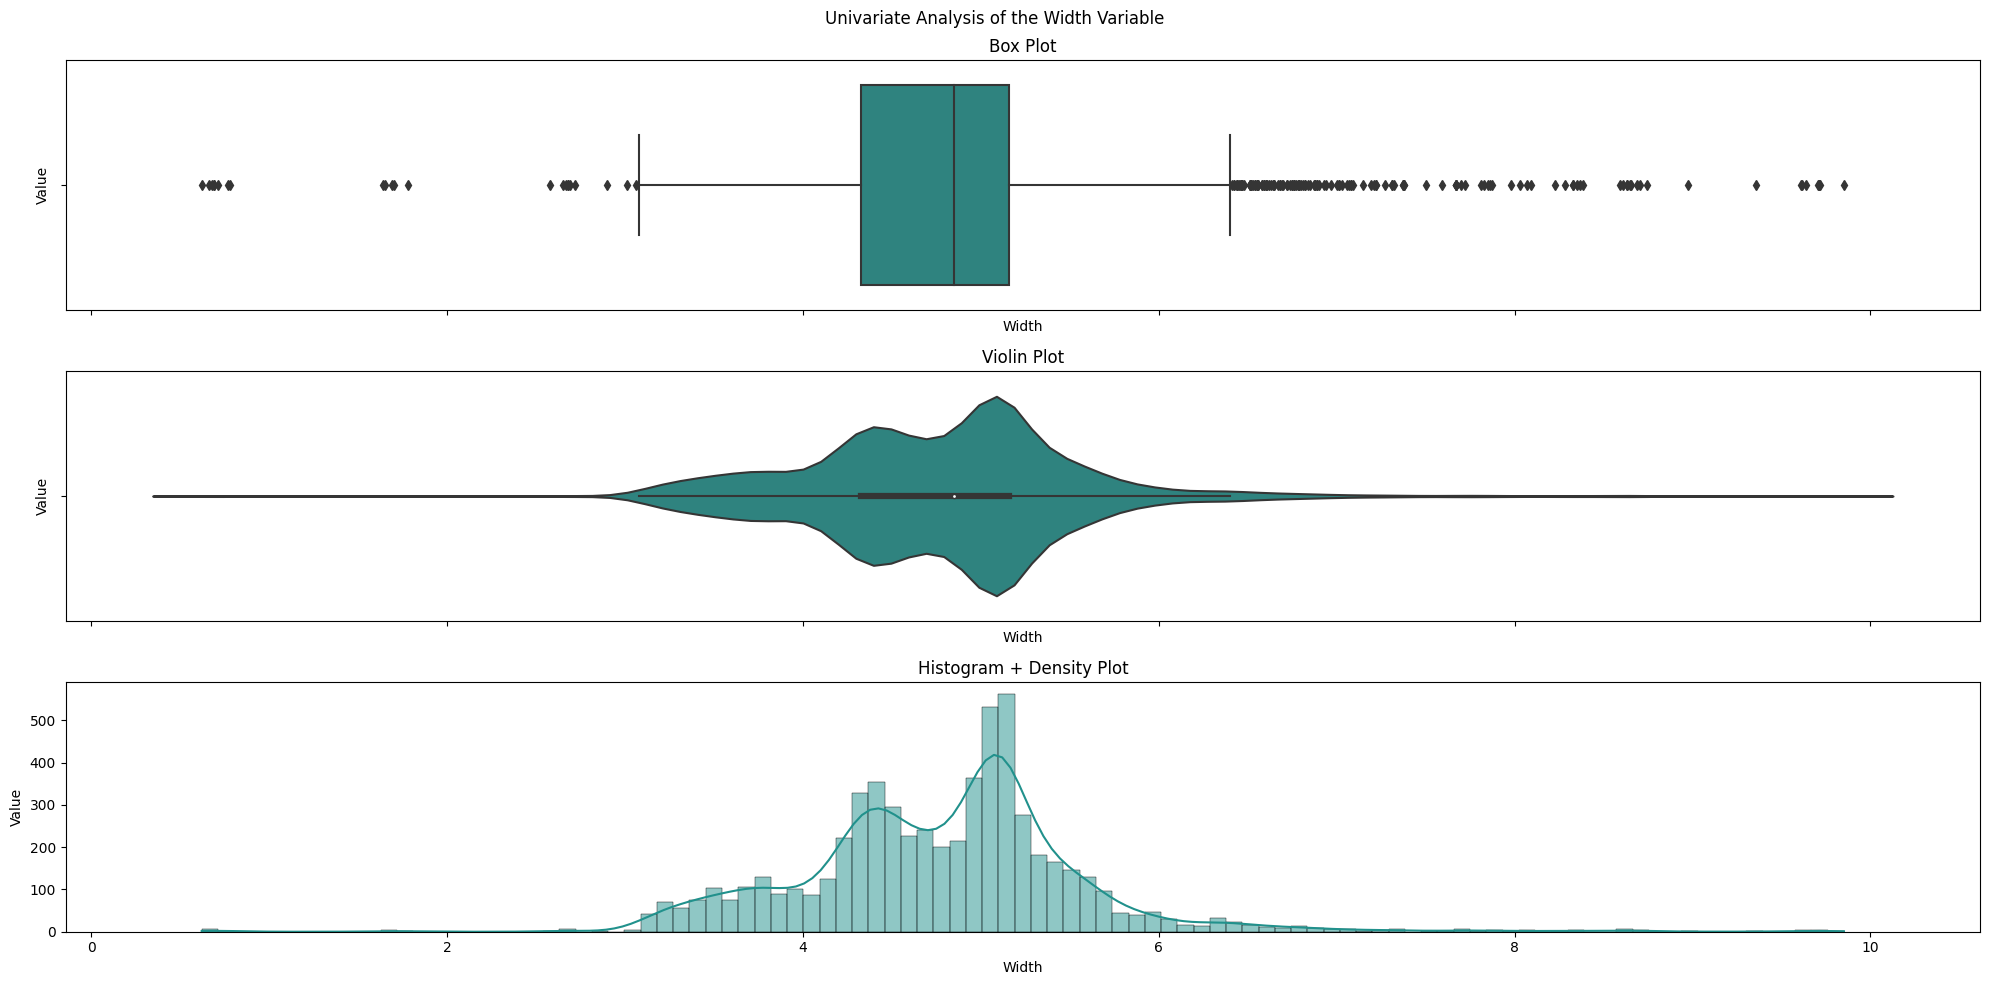

In [14]:
plot_graph_numerical(df.Width)

**Insight 💡**

- The column has 5991 entries, with a mean of 4.771036 and a standard deviation of 0.784624.
- The minimum width is 0.620117 and the maximum width is 9.851562.
- The 25th, 50th (median), and 75th percentiles are 4.328125, 4.851562, and 5.160156, respectively. The interquartile range (IOR) is the difference between the 75th and 25th percentiles, which is 0.832031 in this case.
- The 'var' row represents the variance of the data, which is 0.615635.
- The 'skew' row represents the skewness of the data, which is 0.569460. This indicates that the distribution of widths is slightly skewed to the right.
- The 'kurtosis' row represents the kurtosis of the data, which is 4.783453. This indicates that the distribution is leptokurtic or has heavy tails. This means that the variable has a higher probability of extreme values (outliers) compared to a normal distribution.
- The 'range' row shows the difference between the maximum and minimum values in the column, which is 9.231445.
- The 'lower_bound' and 'upper_bound' rows show the lower and upper bounds for outliers, respectively, using the interquartile range method.
- The 'outliers' row shows the number of values in the column that are considered outliers based on the lower and upper bounds. In this case, there are 164 outliers.

Feature Depth

In [15]:
describe_numerical(df.Depth)

count          5991.000000
mean              3.525825
std               5.266929
min               0.529785
25%               2.740234
50%               3.119141
75%               3.349609
max              94.500000
var              27.740538
skew             13.065566
kurtosis        182.427704
range            93.970215
IOR               0.609375
lower_bound       1.826172
upper_bound       4.263672
outliers        189.000000
Name: Depth, dtype: float64

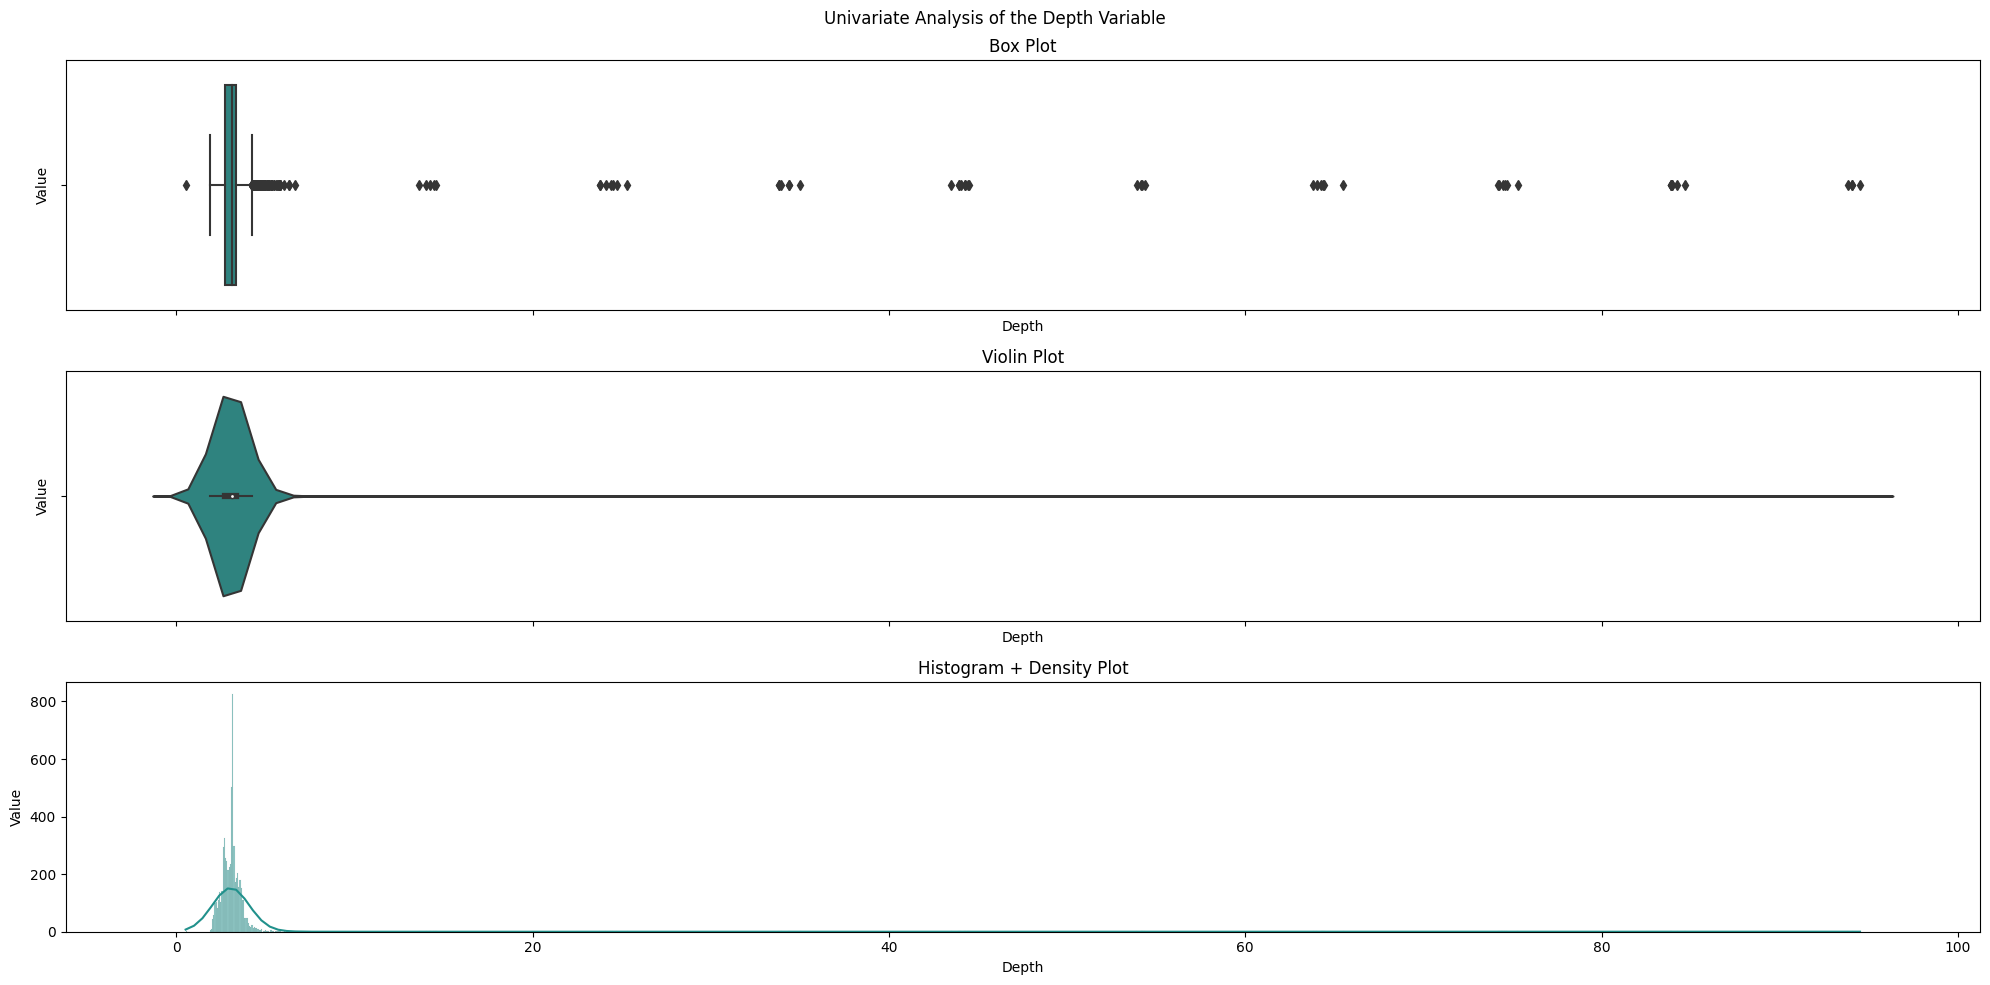

In [16]:
plot_graph_numerical(df.Depth)

**Insight 💡**

- The column has 5991 entries, with a mean of 3.525825 and a standard deviation of 5.266929.
- The minimum depth is 0.529785 and the maximum depth is 94.5.
- The 25th, 50th (median), and 75th percentiles are 2.740234, 3.119141, and 3.349609, respectively. The interquartile range (IOR) is the difference between the 75th and 25th percentiles, which is 0.609375 in this case.
- The 'var' row represents the variance of the data, which is 27.740538.
- The 'skew' row represents the skewness of the data, which is 13.065566. This indicates that the distribution of depths is highly skewed to the right.
- The 'kurtosis' row represents the kurtosis of the data, which is 182.427704. This indicates that the distribution is highly leptokurtic or has heavy tails. This means that the variable has a high probability of extreme values (outliers) compared to a normal distribution.
- The 'range' row shows the difference between the maximum and minimum values in the column, which is 93.970215.
- The 'lower_bound' and 'upper_bound' rows show the lower and upper bounds for outliers, respectively, using the interquartile range method.
- The 'outliers' row shows the number of values in the column that are considered outliers based on the lower and upper bounds. In this case, there are 189 outliers.

## Univalent analysis for categorical data 📊

Let's start with univalent analysis for numerical data

The first function, describe_categorical, takes a pandas DataFrame as input and returns a summary of categorical columns in the DataFrame. If no columns are specified, the function automatically selects all columns of the 'category' data type. The summary includes the count and percentage of each unique value in the column. The function also allows for limiting the number of unique values displayed and the option to include missing values. Overall, this function is useful for getting a quick overview of the categorical data in a DataFrame.

The second function, plot_graph_categorical, takes a pandas Series object representing a single categorical variable and plots two types of graphs: a countplot and a pie chart. The countplot displays the frequency count of each unique value in the variable, while the pie chart shows the distribution of values as a percentage of the total. The function also sets up the axes labels, title, and dimensions for the figure. This function is useful for visualizing the distribution of a single categorical variable.

In [17]:
def describe_categorical(df, columns=None, n=25, include_missing=True):
    if columns is None:
        columns = df.select_dtypes(include=['category']).columns.tolist()
    stats = pd.DataFrame(columns=['count', 'percentage'])
    total = df.shape[0]
    for col in columns:
        if include_missing:
            values, counts = df[col].value_counts(dropna=False).index.tolist(), df[col].value_counts(dropna=False).values.tolist()
        else:
            values, counts = df[col].value_counts().index.tolist(), df[col].value_counts().values.tolist()
        if n is not None:
            values = values[:n]
            counts = counts[:n]
        stats_col = pd.DataFrame({'column': col, 'value': values, 'count': counts})
        stats_col['percentage'] = stats_col['count'] / total * 100
        stats = pd.concat([stats, stats_col], ignore_index=False)
    stats.set_index(['column', 'value','count', 'percentage'], inplace=True)
    return stats.sort_index()


In [18]:
def plot_graph_categorical(data):
    
    values, counts = np.unique(data, return_counts=True)
    sorted_idx = np.argsort(-counts)
    values = values[sorted_idx]
    counts = counts[sorted_idx]
    
    f, (ax_bar,ax_pie) = plt.subplots(1,2)
    
    sns.countplot(x=data, ax=ax_bar,order = data.value_counts().index, palette="viridis")
    ax_bar.set(xlabel=data.name, ylabel='Count', title=f'Count of Diamonds by {data.name}')
    for i in ax_bar.containers:
        ax_bar.bar_label(i,)
    
    color_palette = sns.color_palette("viridis", len(values)).as_hex()
    
    plt.title(f'Distribution of Diamonds by {data.name}')
    ax_pie = plt.pie(counts, labels=values, startangle=90, counterclock=False, autopct='%.0f%%', colors=color_palette, textprops={"color": "#bbbbbb"})


    f.suptitle(f'Univariate Analysis of the {data.name} Variable')

    f.set_figwidth(20)
    f.set_figheight(10)
    plt.tight_layout()
    plt.show()

List of categorical columns present in dataset

In [19]:
df.select_dtypes(exclude=np.number).columns

Index(['Id', 'Shape', 'Clarity', 'Colour', 'Cut', 'Polish', 'Symmetry',
       'Fluorescence'],
      dtype='object')

Feature Shape

In [20]:
describe_categorical(df, columns=["Shape"])

Empty DataFrame
Columns: []
Index: [(Shape, CUSHION, 1662, 27.74161241862794), (Shape, EMERALD, 550, 9.180437322650642), (Shape, HEART, 345, 5.758637956935403), (Shape, MARQUISE, 68, 1.1350358871640793), (Shape, OVAL, 678, 11.316975463194792), (Shape, PEAR, 302, 5.040894675346353), (Shape, PRINCESS, 624, 10.41562343515273), (Shape, ROUND, 1762, 29.410782840928057)]

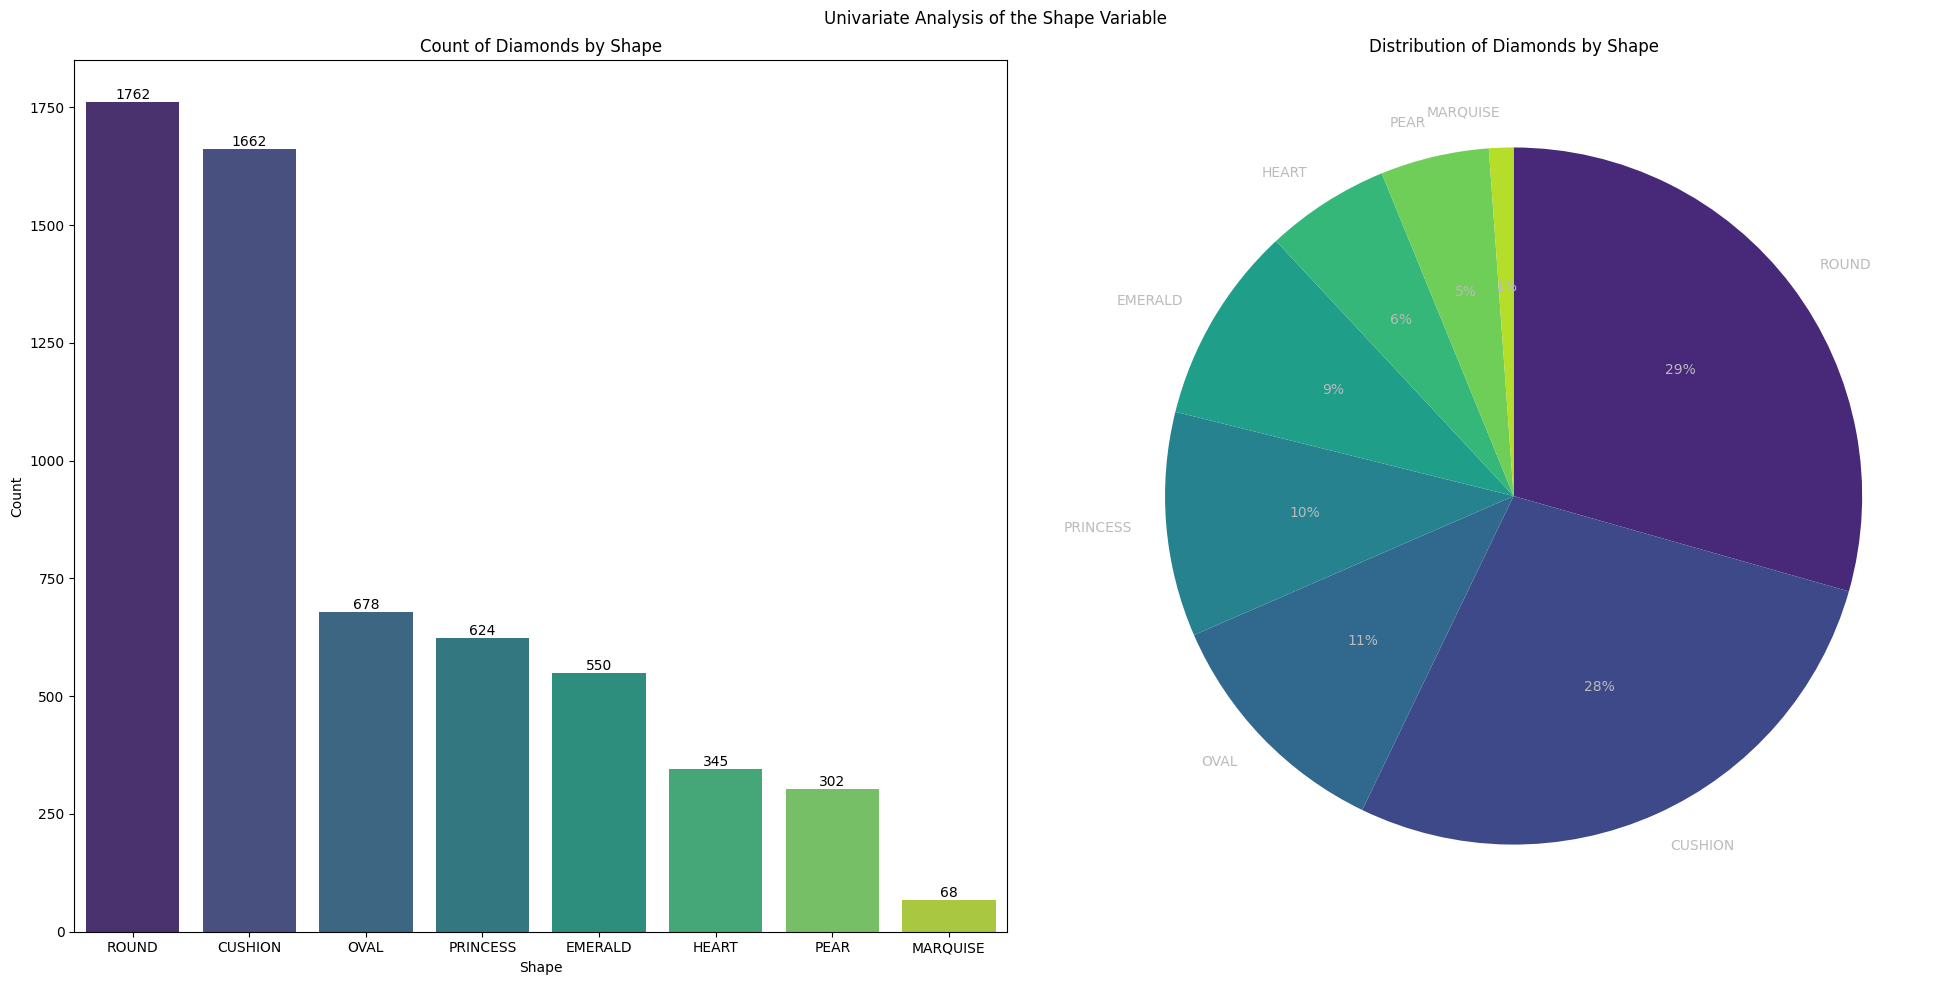

In [21]:
plot_graph_categorical(df.Shape)

**Insight 💡**

- The most common diamond shape in the dataset is cushion, accounting for 27.7% of all diamonds.
- The second most common shape is round, representing 29.4% of all diamonds.
- Other shapes, such as emerald, oval, and princess, are also relatively common, each accounting for over 5% of all diamonds.
- Heart and marquise are the least common shapes, each representing less than 2% of all diamonds.
- This information can be useful for understanding the preferences of diamond buyers and the market demand for different diamond shapes.
- The data could be further analyzed by examining how the distribution of diamond shapes varies by other factors, such as price

In [22]:
describe_categorical(df, columns=["Clarity"])

Empty DataFrame
Columns: []
Index: [(Clarity, FL, 1, 0.016691704223001168), (Clarity, I1, 40, 0.6676681689200467), (Clarity, I2, 7, 0.11684192956100817), (Clarity, I3, 1, 0.016691704223001168), (Clarity, IF, 83, 1.385411450509097), (Clarity, SI1, 1424, 23.768986813553663), (Clarity, SI2, 996, 16.624937406109165), (Clarity, VS1, 1099, 18.344182941078284), (Clarity, VS2, 1303, 21.74929060257052), (Clarity, VVS1, 438, 7.310966449674512), (Clarity, VVS2, 599, 9.9983308295777)]

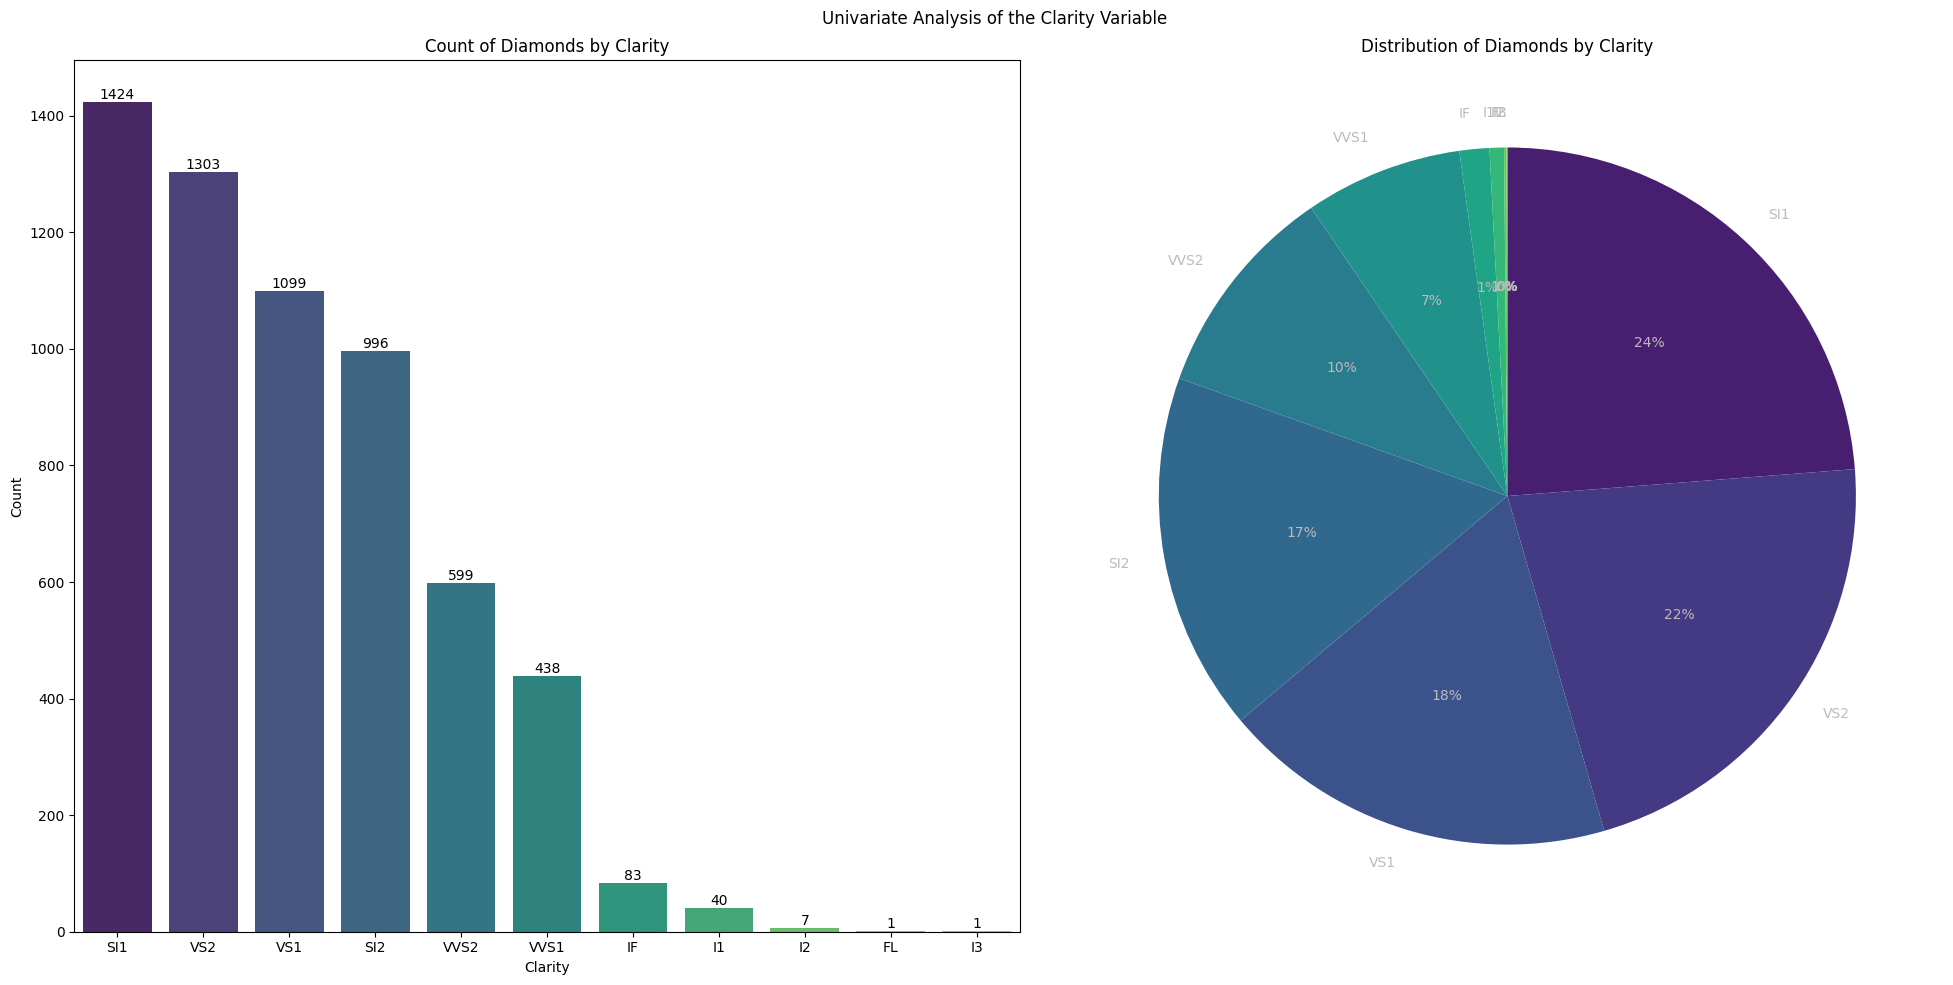

In [23]:
plot_graph_categorical(df.Clarity)

**Insight 💡**

- The majority of diamonds in the dataset have a clarity rating of either VS2 (21.7%) or SI1 (23.8%).
- The least common clarity ratings are FL, I3, and I2, each accounting for less than 1% of all diamonds.
- The clarity rating of a diamond is an important factor in determining its value, with higher clarity ratings typically commanding higher prices.
- The dataset could be further analyzed to explore how the distribution of clarity ratings varies by other factors, such as carat weight or color grade.
- The low percentage of diamonds with the FL clarity rating could indicate that such diamonds are rare and highly valued.

In [24]:
describe_categorical(df, columns=["Colour"])

Empty DataFrame
Columns: []
Index: [(Colour, D, 748, 12.485394758804874), (Colour, E, 901, 15.039225504924053), (Colour, F, 924, 15.42313470205308), (Colour, FANCY, 256, 4.273076281088299), (Colour, G, 701, 11.700884660323819), (Colour, H, 562, 9.380737773326658), (Colour, I, 653, 10.899682857619764), (Colour, J, 515, 8.596227674845602), (Colour, K, 309, 5.157736604907361), (Colour, L, 172, 2.8709731263562013), (Colour, M, 88, 1.4688699716241027), (Colour, N, 46, 0.7678183942580538), (Colour, O, 1, 0.016691704223001168), (Colour, O-P, 12, 0.20030045067601399), (Colour, Q-R, 6, 0.10015022533800699), (Colour, S-T, 15, 0.25037556334501754), (Colour, U-V, 35, 0.5842096478050409), (Colour, W, 1, 0.016691704223001168), (Colour, W-X, 34, 0.5675179435820397), (Colour, Y-Z, 12, 0.20030045067601399)]

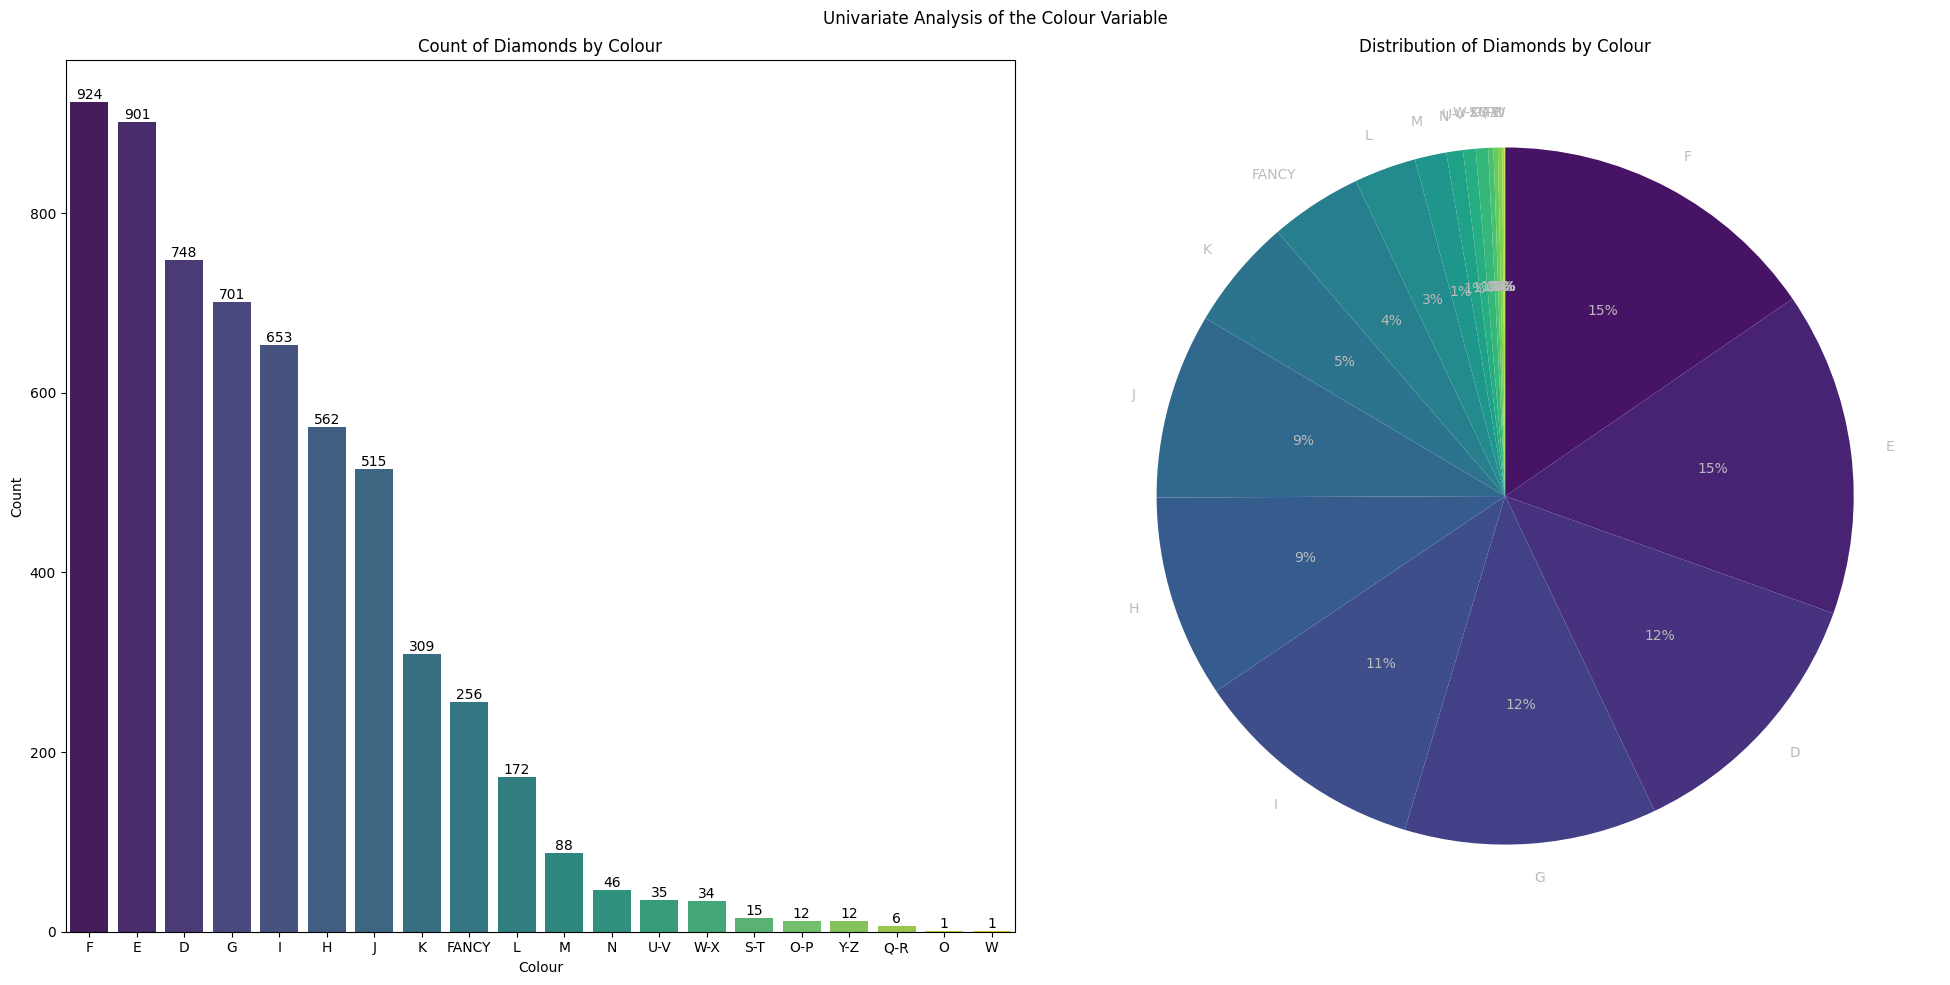

In [25]:
plot_graph_categorical(df.Colour)

**Insight 💡**

- The most common diamond color in the dataset is F, accounting for 15.42% of all diamonds, followed closely by E with 15.04% and D with 12.49%.
- The category "Fancy" represents a small percentage of the dataset (4.27%), indicating that non-standard colors are less common in diamonds.
- Colors from G to J are also relatively common, with each accounting for between 8-11% of all diamonds.
- Less common colors are K to M, which represent between 1.47% to 5.16% of all diamonds.
- The least common colors in the dataset are O, Q-R, and W, each representing less than 0.25% of all diamonds.
- This information can be useful for understanding the preferences of diamond buyers and the market demand for different diamond colors.
- The data could be further analyzed by examining how the distribution of diamond colors varies by other factors, such as price or shape. Additionally, comparing the distribution of diamond colors to market demand could be useful for determining potential areas of opportunity in the diamond market

In [26]:
describe_categorical(df, columns=["Cut"])

Empty DataFrame
Columns: []
Index: [(Cut, EX, 4380, 73.10966449674513), (Cut, F, 17, 0.28375897179101983), (Cut, GD, 302, 5.040894675346353), (Cut, VG, 1292, 21.56568185611751)]

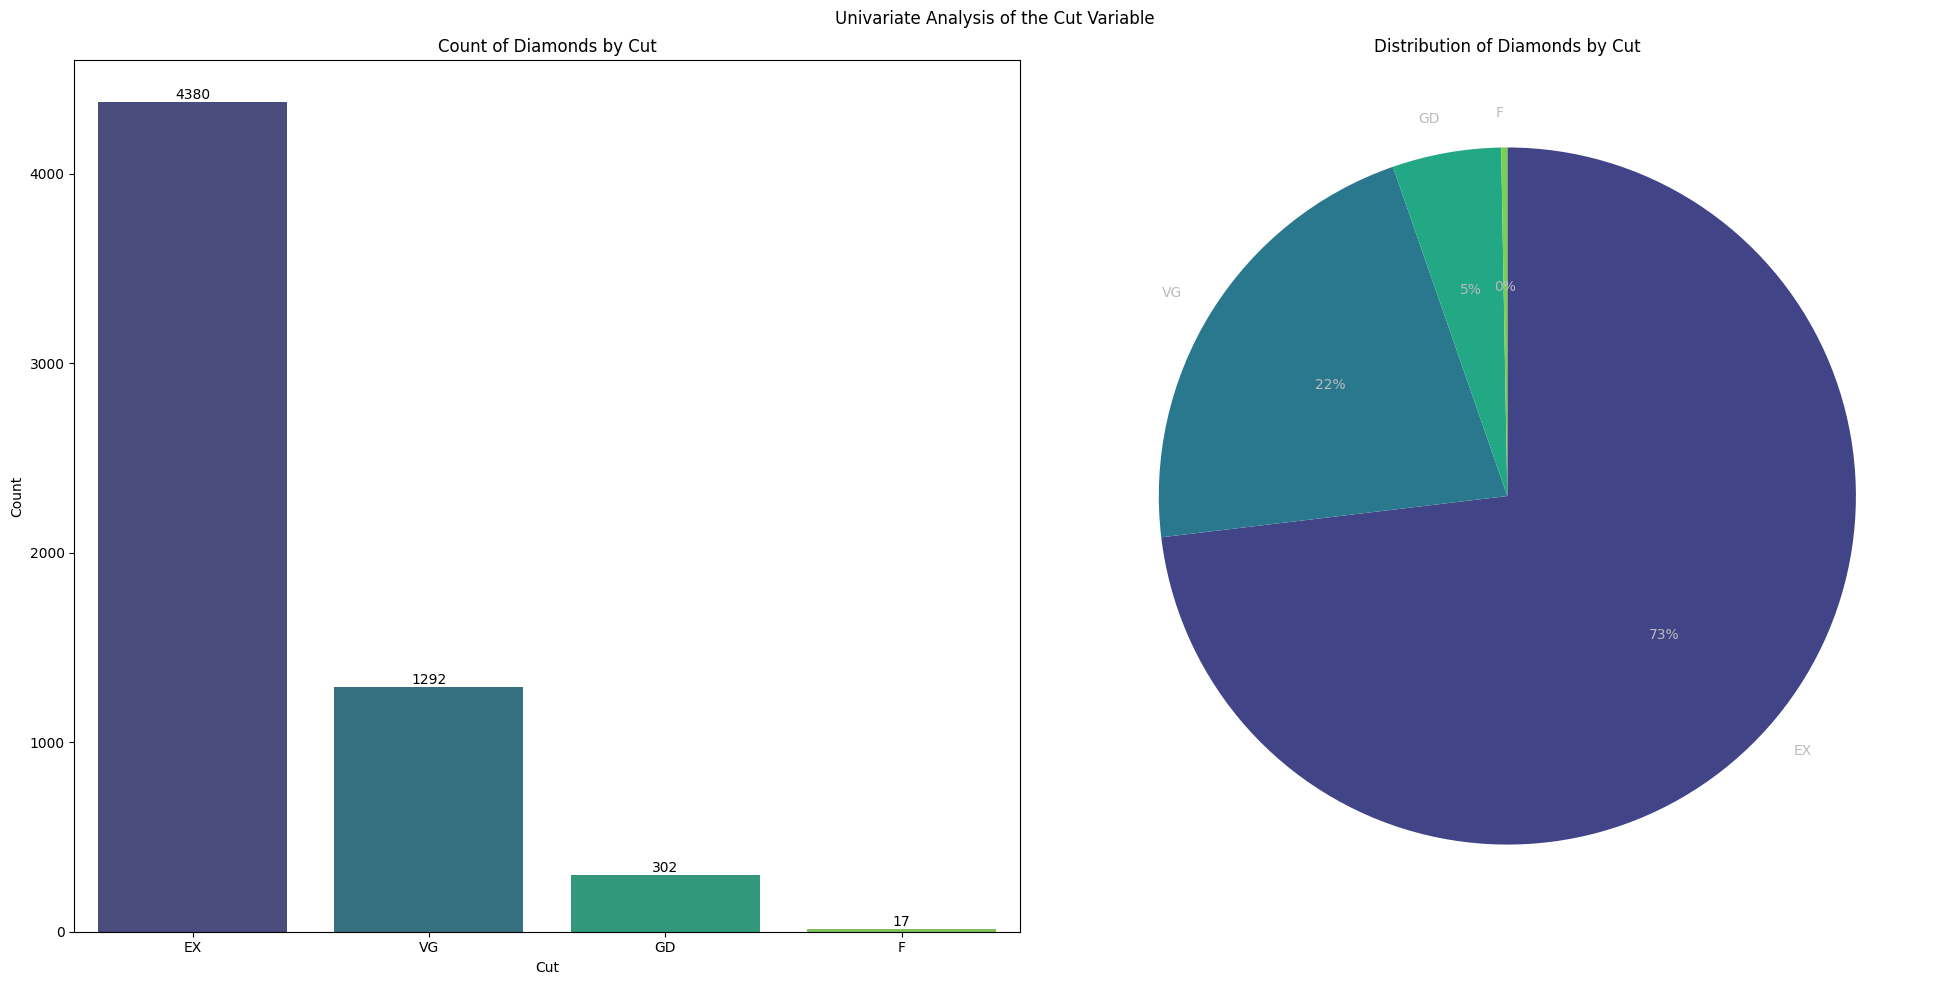

In [27]:
plot_graph_categorical(df.Cut)

**Insight 💡**

- The majority of diamonds in the dataset have an excellent cut, accounting for 73.1% of all diamonds.
- Very good and good cuts are also relatively common, representing 21.6% and 5% of all diamonds respectively.
- Only a small percentage of diamonds in the dataset have a fair or poor cut, with less than 1% of diamonds falling into these categories.
- The cut of a diamond is an important factor in determining its overall appearance and beauty, and can have a significant impact on its value. Therefore, understanding the distribution of diamond cuts can provide insight into the preferences of diamond buyers and the market demand for different types of cuts.

In [28]:
describe_categorical(df, columns=["Polish"])

Empty DataFrame
Columns: []
Index: [(Polish, EX, 4781, 79.80303789016858), (Polish, F, 1, 0.016691704223001168), (Polish, GD, 63, 1.0515773660490735), (Polish, VG, 1146, 19.128693039559337)]

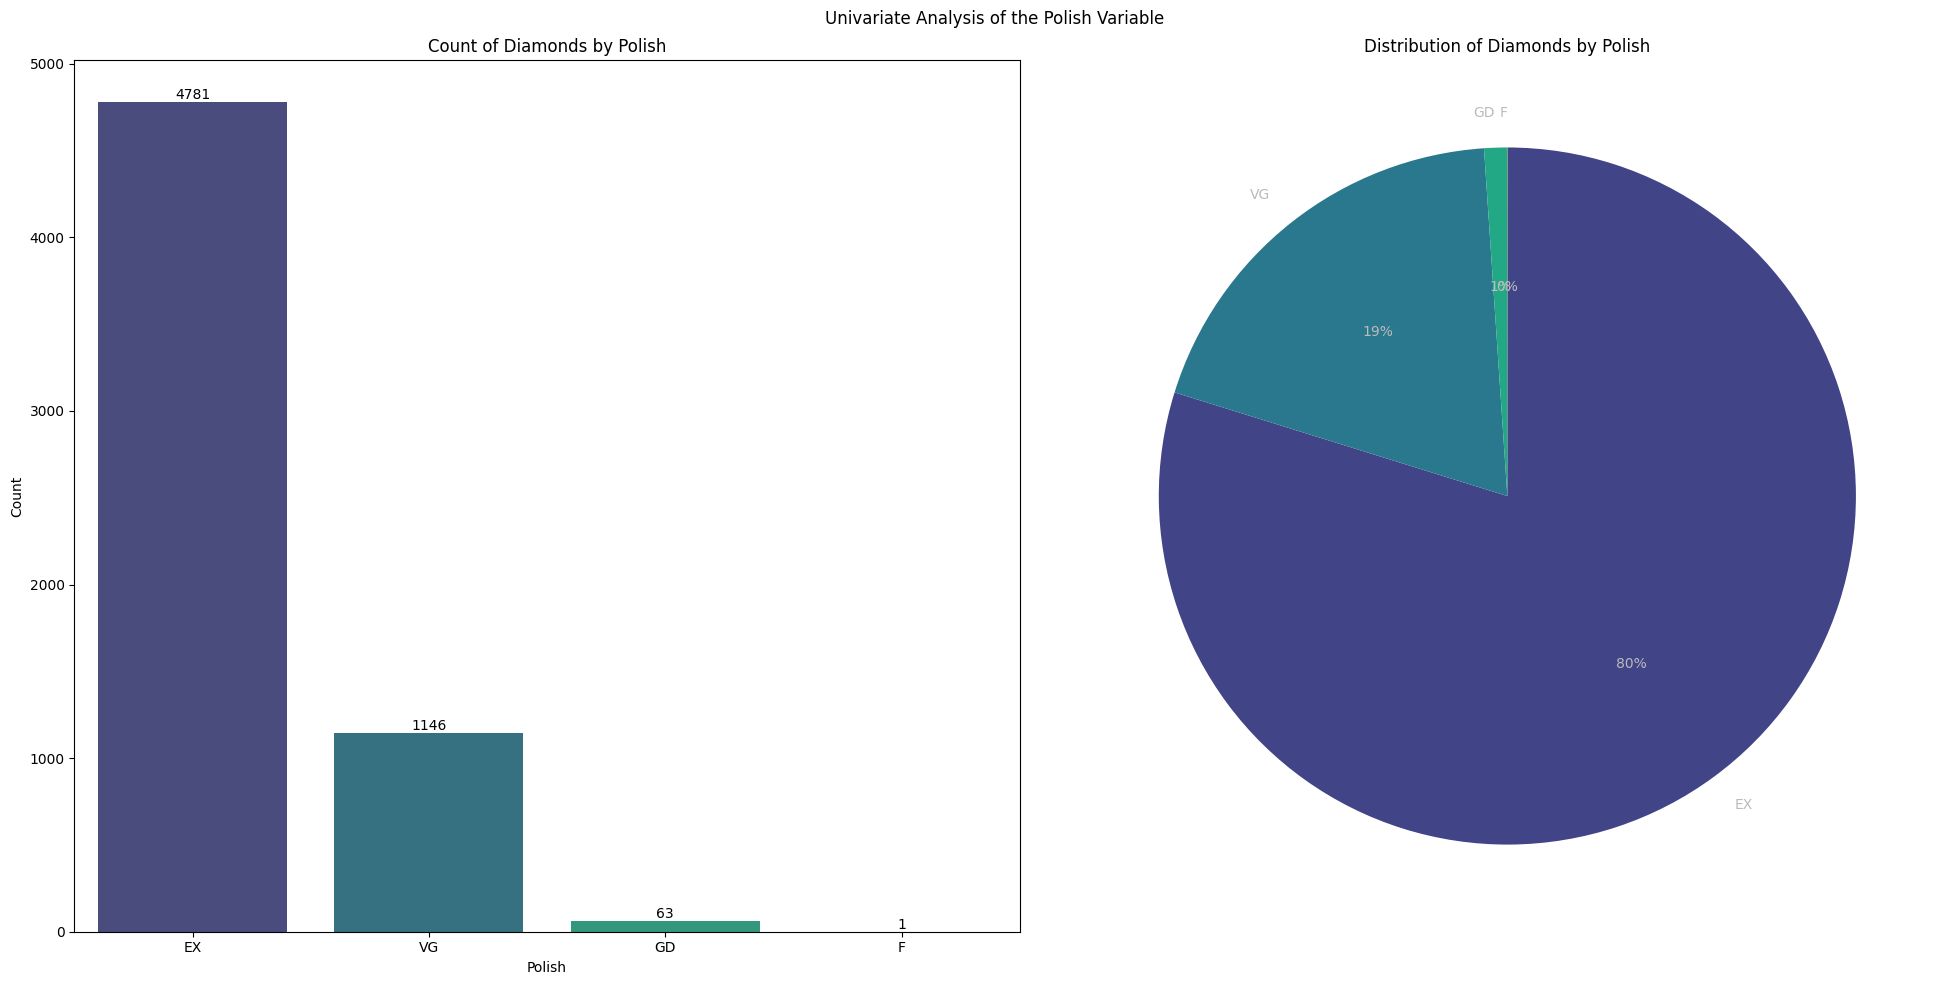

In [29]:
plot_graph_categorical(df.Polish)

**Insight 💡**

- The majority of diamonds in the dataset have an "excellent" polish rating, accounting for 79.8% of all diamonds.
- 19.1% of diamonds have a "very good" polish rating, while only a small percentage have a "good" or "fair" rating.
- This information can be useful for understanding the importance of polish in diamond quality and how it may affect pricing and market demand.
- The data could be further analyzed by examining how the distribution of polish ratings varies by other factors, such as diamond price.

In [30]:
describe_categorical(df, columns=["Symmetry"])

Empty DataFrame
Columns: []
Index: [(Symmetry, EX, 1698, 28.342513770655987), (Symmetry, FR, 54, 0.9013520280420632), (Symmetry, GD, 1056, 17.626439659489236), (Symmetry, VG, 3183, 53.129694541812725)]

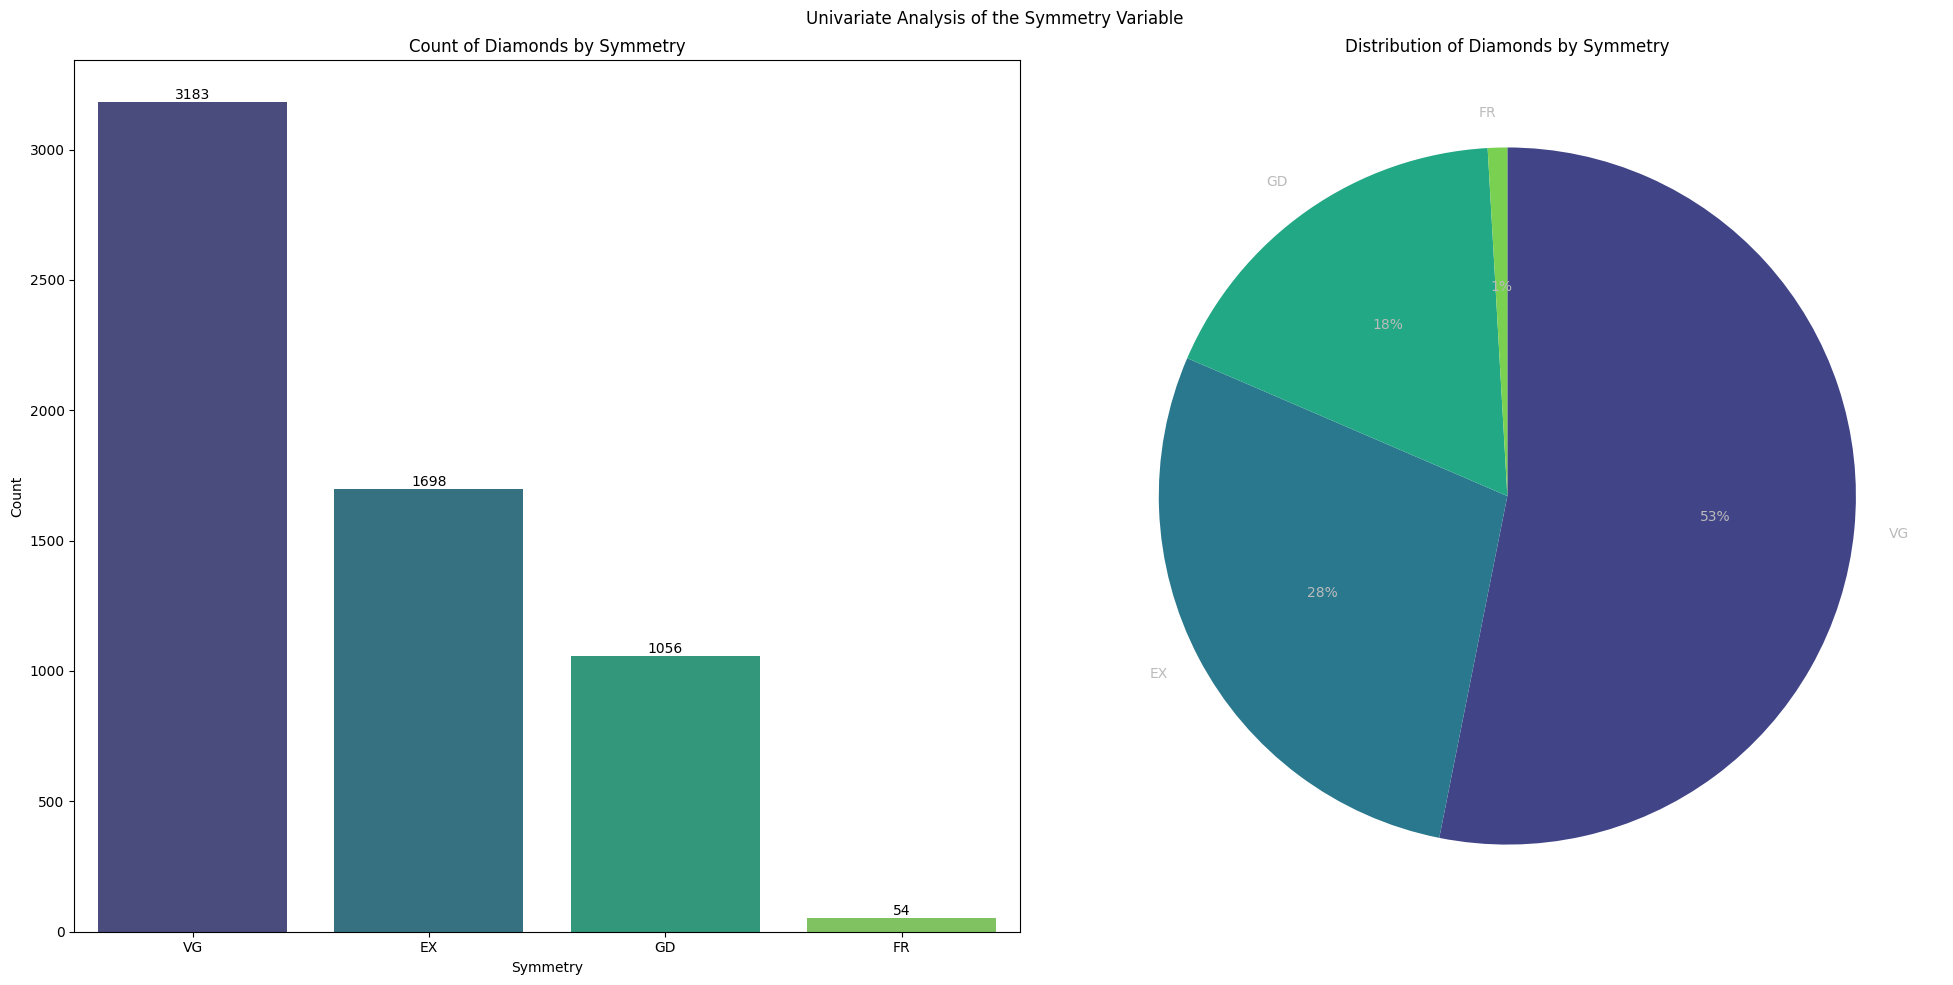

In [31]:
plot_graph_categorical(df.Symmetry)

**Insight 💡**

- The majority of diamonds in the dataset have excellent (EX) symmetry, accounting for 28.3% of all diamonds.
- Very good (VG) symmetry is the next most common, representing over half (53.1%) of all diamonds.
- Good (GD) symmetry accounts for 17.6% of all diamonds, while fair (FR) symmetry represents less than 1%.
- The information on diamond symmetry can be valuable in assessing a diamond's overall quality and value.
- Further analysis could be done to examine how symmetry relates to other factors, such as cut, clarity, and price.

In [32]:
describe_categorical(df, columns=["Fluorescence"])

Empty DataFrame
Columns: []
Index: [(Fluorescence, F, 1117, 18.644633617092303), (Fluorescence, M, 456, 7.611417125688533), (Fluorescence, N, 4141, 69.12034718744783), (Fluorescence, SL, 6, 0.10015022533800699), (Fluorescence, ST, 243, 4.056084126189284), (Fluorescence, VS, 19, 0.3171423802370222), (Fluorescence, VSL, 9, 0.15022533800701052)]

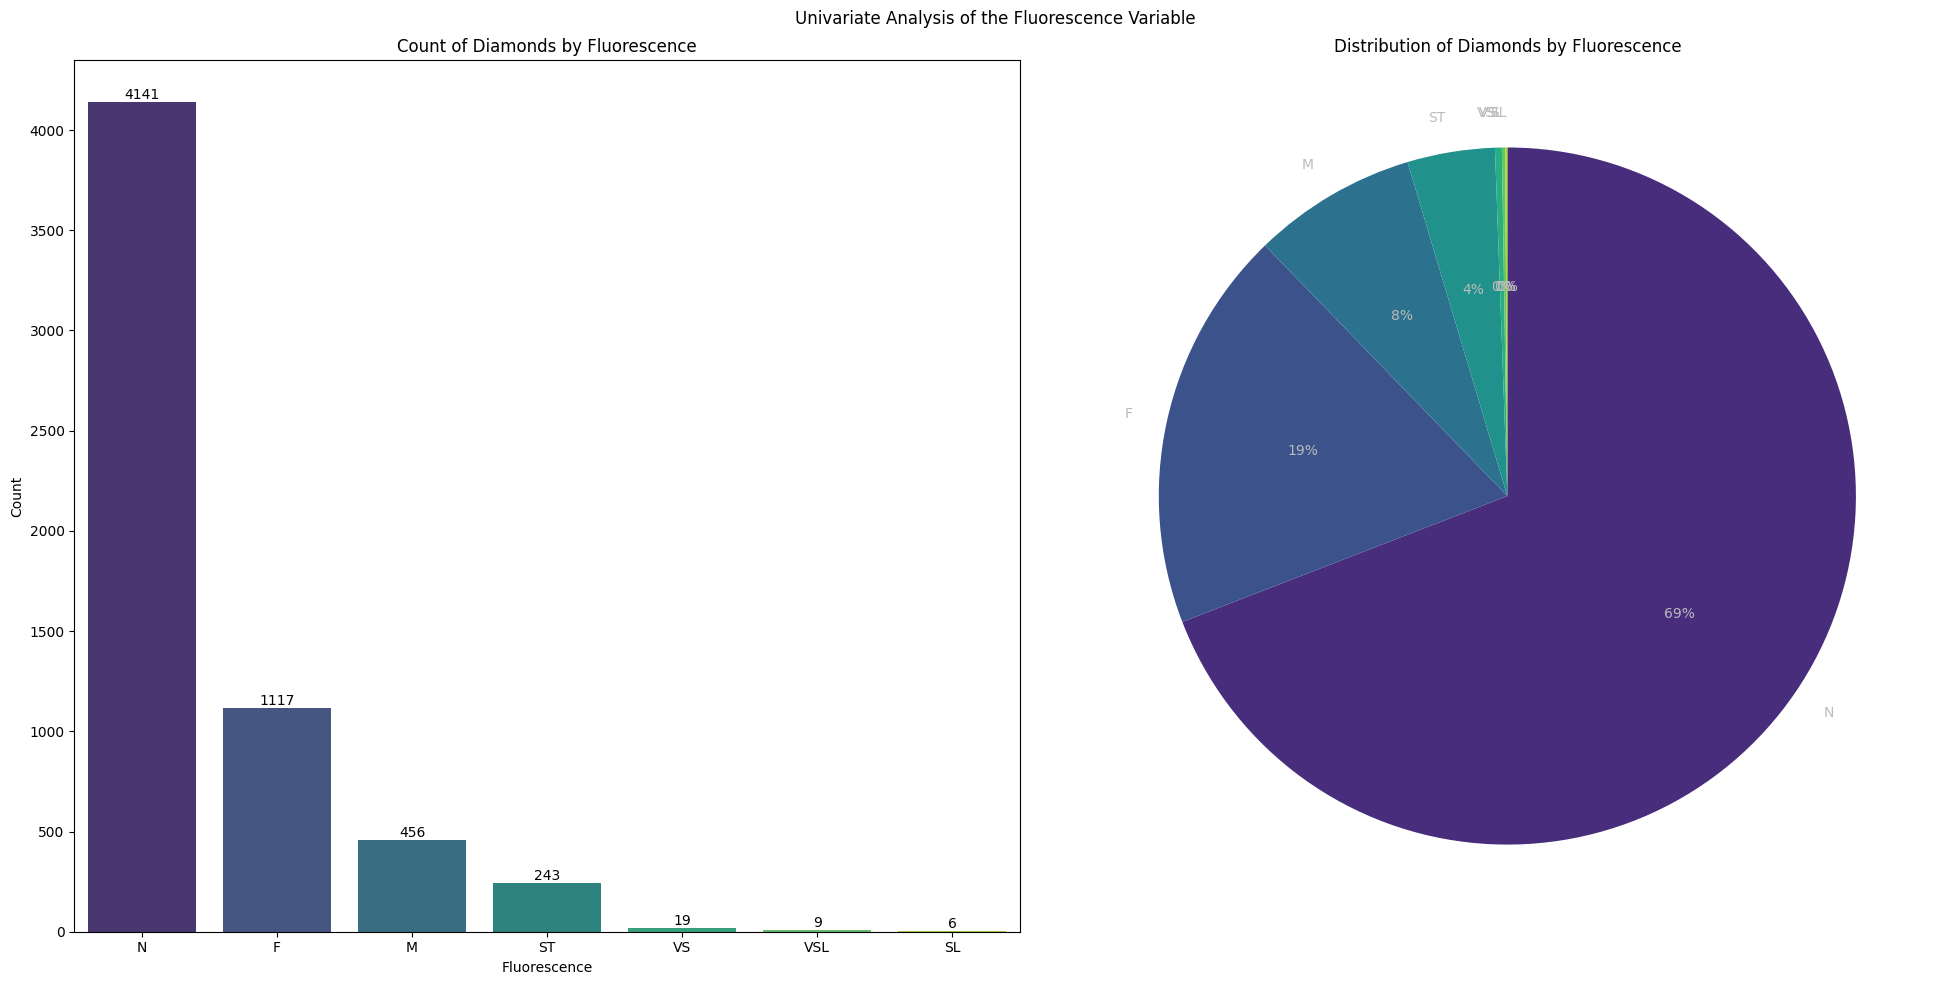

In [33]:
plot_graph_categorical(df.Fluorescence)

**Insight 💡**

- The majority of diamonds in the dataset (69.1%) have no fluorescence or are considered "none" (N).
- The second most common fluorescence is faint (F), accounting for 18.6% of all diamonds.
- Medium (M), strong (ST), and very strong (VSL) fluorescence are the least common, each representing less than 5% of all diamonds.
- This information can be useful for understanding the prevalence of fluorescence in diamonds and its impact on diamond appearance and value.
- Further analysis could explore how the distribution of fluorescence varies by other diamond characteristics, such as color and clarity, and how it affects diamond pricing.

## Bivalent analysis for categorical data 📊

Let's start with Bivalent analysis using groupby

The first function describe_categorical_grouped takes a pandas DataFrame as an input and returns a summary of a categorical column grouped by another column in the DataFrame. The summary includes basic statistics like count, frequency percentage, and quartiles. Additionally, it includes variance, skewness, kurtosis, range, interquartile range (IOR), lower and upper bounds, and the number of outliers for each group. The function is useful for quickly getting a comprehensive overview of the categorical data in a DataFrame, grouped by another column.

The second function groupby_violinplot is used to plot a violin plot for a numerical variable grouped by a categorical variable. The function takes a pandas DataFrame as input along with the x and y variables to be plotted, and the hue variable (optional). The function creates a violin plot for the variable y, grouped by the variable x, and colored by the hue variable if provided. The function is useful for visualizing the distribution of a numerical variable across different categories and for identifying any differences in the distribution. The function also sets up the title, axes labels, and plot dimensions for the figure.

In [34]:
def describe_categorical_grouped(df, group_col, col):
    group_stats = df.groupby(group_col)[col].describe()
    group_stats = group_stats.join(pd.DataFrame(df.groupby(group_col)[col].var().tolist(), columns=['var'], index=group_stats.index))
    group_stats = group_stats.join(pd.DataFrame(df.groupby(group_col)[col].skew().tolist(), columns=['skew'], index=group_stats.index))
    group_stats = group_stats.join(pd.DataFrame(df.groupby(group_col)[col].apply(pd.DataFrame.kurt).tolist(), columns=['kurtosis'], index=group_stats.index))
    
    group_stats = group_stats.join(pd.DataFrame((group_stats['max'].values - group_stats['min'].values).tolist(), columns=['range'], index=group_stats.index))
    group_stats = group_stats.join(pd.DataFrame((group_stats['75%'].values - group_stats['25%'].values).tolist(), columns=['IOR'], index=group_stats.index))
    group_stats = group_stats.join(pd.DataFrame((group_stats['25%'].values - 1.5 * group_stats['IOR'].values).tolist(), columns=['lower_bound'], index=group_stats.index))
    group_stats = group_stats.join(pd.DataFrame((group_stats['75%'].values + 1.5 * group_stats['IOR'].values).tolist(), columns=['upper_bound'], index=group_stats.index))
    
    outliers = df.groupby(group_col, group_keys=True)[col].apply(lambda x: (x < x.quantile(0.25) - 1.5*(x.quantile(0.75) - x.quantile(0.25))) | (x > x.quantile(0.75) + 1.5*(x.quantile(0.75) - x.quantile(0.25)))).groupby(group_col, group_keys=True).sum()
    group_stats = group_stats.join(pd.DataFrame((outliers.values).tolist(), columns=['outliers'], index=group_stats.index))
    return group_stats

In [35]:
def groupby_violinplot(df, x, y, hue=None, order=None):
    plt.figure(figsize=(15,8))
    sns.violinplot(data=df, x=x, y=y, hue=hue, order=order, palette="viridis")
    plt.title(f'Distribution of {y} by {x}')
    plt.show()

Exploring the Relationship between Clarity and Price of Diamonds.

In [36]:
describe_categorical_grouped(df, ['Clarity'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Clarity,,,,,,,,,,,,,,,,
FL,1.0,64896.070312,NaN,64896.070312,64896.070312,64896.070312,64896.070312,64896.070312,NaN,NaN,NaN,0.000000,0.000000,64896.070312,64896.070312,0
I1,40.0,4368.747070,10588.132812,765.119995,1534.520020,2020.365051,2942.169983,67570.367188,112108600.0,5.766176,34.773056,66805.247192,1407.649963,-576.954926,5053.644928,4
I2,7.0,7236.025879,14275.443359,922.669983,1084.890015,1731.040039,3148.650024,39531.390625,203788272.0,2.619309,6.891067,38608.720642,2063.760010,-2010.750000,6244.290039,1
I3,1.0,1323.079956,NaN,1323.079956,1323.079956,1323.079956,1323.079956,1323.079956,NaN,NaN,NaN,0.000000,0.000000,1323.079956,1323.079956,0
IF,83.0,3582.920654,6267.741699,837.190002,1178.844971,1518.969971,2451.369995,35945.050781,39284588.0,3.855964,15.396164,35107.860779,1272.525024,-729.942566,4360.157532,12
SI1,1424.0,2437.262939,2636.485596,683.219971,1452.954956,2030.209961,2365.132568,39433.289062,6951048.5,7.035566,70.467758,38750.069092,912.177612,84.688538,3733.398987,134
SI2,996.0,2678.904785,2610.068848,778.969971,1551.657471,2062.095093,2599.270081,41719.089844,6812463.5,5.968571,59.724911,40940.119873,1047.612610,-19.761444,4170.688995,99
VS1,1099.0,2188.702637,3388.112793,718.919983,1142.609985,1650.319946,2094.099976,68738.523438,11479314.0,12.683416,207.180191,68019.603455,951.489990,-284.625000,3521.334961,96
VS2,1303.0,2489.632324,5086.681152,754.500000,1264.100037,1793.229980,2166.619995,76147.679688,25874332.0,10.173996,118.412422,75393.179688,902.519958,-89.679901,3520.399933,97


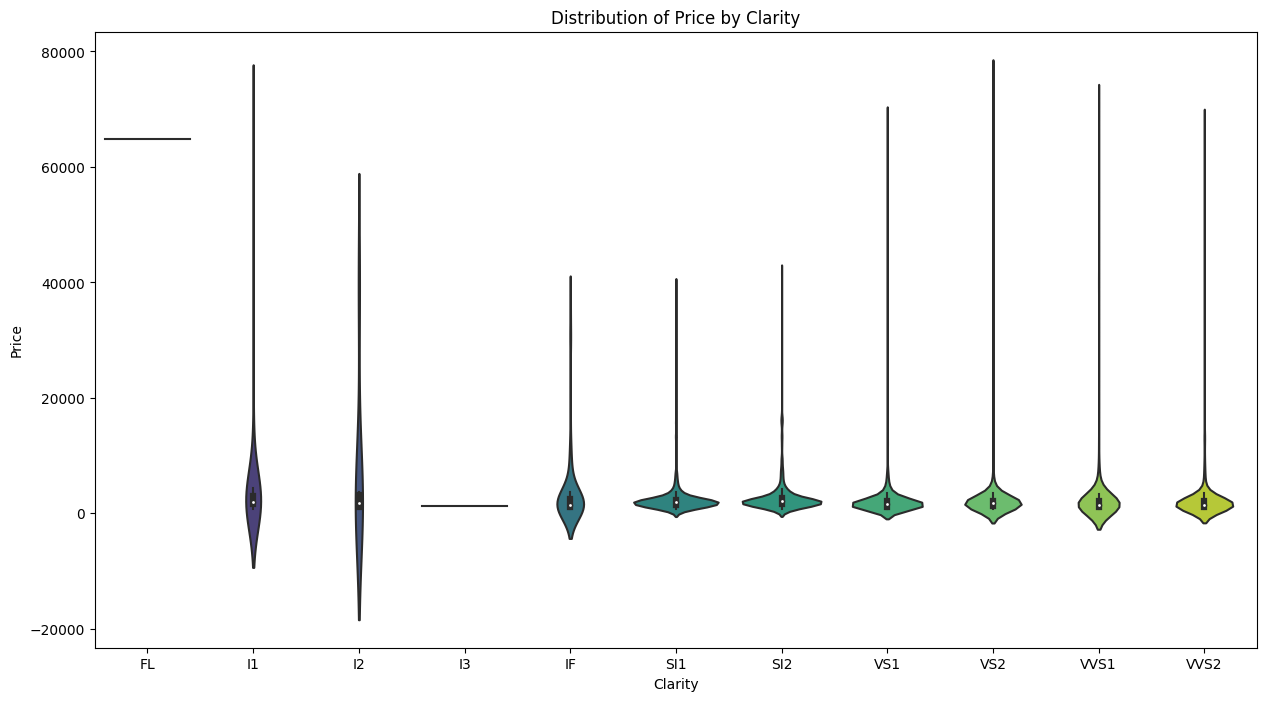

In [37]:
groupby_violinplot(df, "Clarity", "Price")

Exploring the Relationship between Colour and Price of Diamonds.

In [38]:
describe_categorical_grouped(df, ['Colour'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Colour,,,,,,,,,,,,,,,,
D,748.0,2550.847900,5157.944336,791.330017,1131.512512,1714.390015,2091.409912,76147.679688,2.660439e+07,8.681926,91.802361,75356.349670,959.897400,-308.333588,3531.256012,62
E,901.0,2149.802490,3500.832275,836.200012,1142.489990,1705.310059,2109.379883,64896.070312,1.225582e+07,14.140841,236.854324,64059.870300,966.889893,-307.844849,3559.714722,55
F,924.0,2419.841797,3554.241455,781.640015,1206.700012,1877.969971,2119.272461,55408.519531,1.263263e+07,8.835156,98.652145,54626.879517,912.572449,-162.158661,3488.131134,100
FANCY,256.0,4809.030762,9976.465820,792.859985,1567.067474,2247.534912,3303.450073,70749.531250,9.952991e+07,4.757150,23.994329,69956.671265,1736.382599,-1037.506424,5908.023972,29
G,701.0,2615.777344,4313.951660,809.510010,1317.619995,1870.829956,2366.590088,67616.140625,1.861020e+07,10.532560,140.348846,66806.630615,1048.970093,-255.835144,3940.045227,75
H,562.0,2800.719727,4639.353027,794.369995,1338.737457,1821.700012,2662.652588,74875.062500,2.152361e+07,9.626762,122.616661,74080.692505,1323.915131,-647.135239,4648.525284,47
I,653.0,2308.907471,2299.638916,786.710022,1400.199951,2006.180054,2337.050049,37753.269531,5.288338e+06,7.963439,96.463707,36966.559509,936.850098,-5.075195,3742.325195,59
J,515.0,2217.944092,1711.629395,746.809998,1453.155029,2041.079956,2200.175049,15891.750000,2.929675e+06,5.362943,34.627403,15144.940002,747.020020,332.625000,3320.705078,42
K,309.0,1967.789185,1710.808350,750.969971,1185.319946,1534.520020,2092.959961,16480.380859,2.926866e+06,5.713089,39.993645,15729.410889,907.640015,-176.140076,3454.419983,18


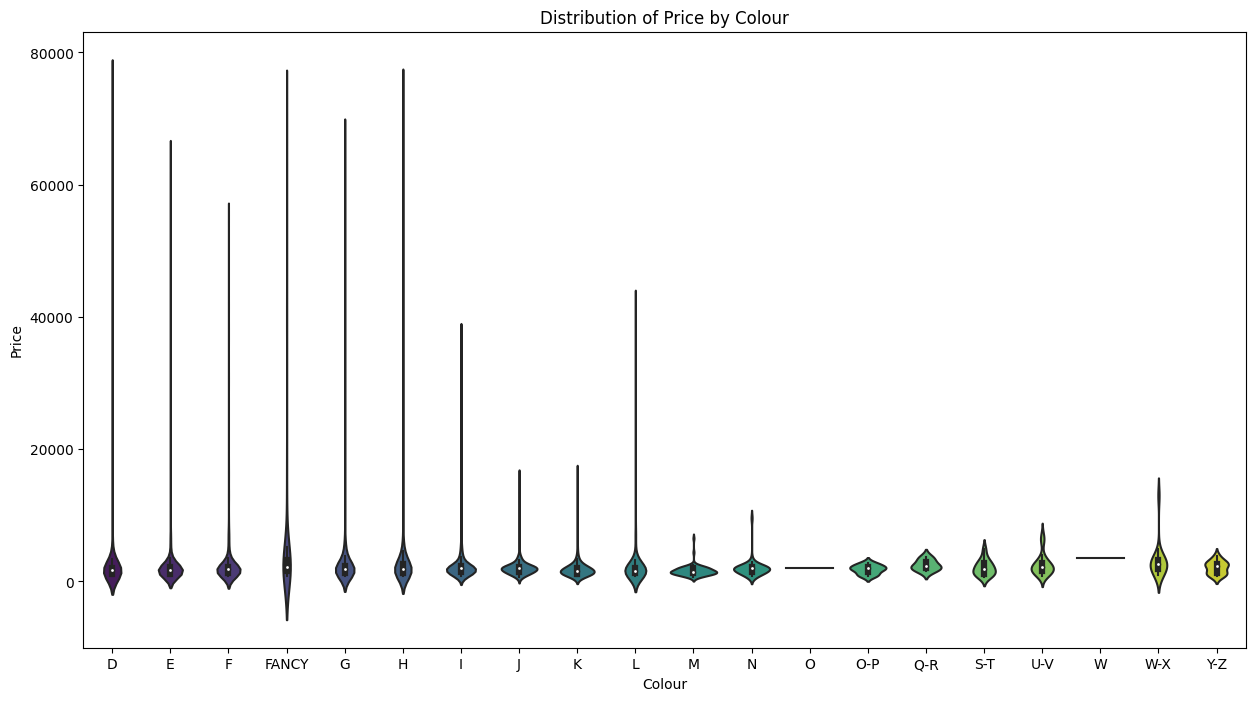

In [39]:
groupby_violinplot(df, "Colour", "Price")

Exploring the Relationship between Cut and Price of Diamonds.

In [40]:
describe_categorical_grouped(df, ['Cut'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Cut,,,,,,,,,,,,,,,,
EX,4380.0,2482.460938,4316.880859,683.219971,1281.895020,1815.270020,2282.582581,74875.062500,1.863546e+07,10.326140,129.828430,74191.842529,1000.687561,-219.136322,3783.613922,349
F,17.0,1930.894775,194.978668,1530.170044,1967.650024,1984.060059,2044.359985,2109.379883,3.801668e+04,-1.634964,1.235364,579.209839,76.709961,1852.585083,2159.424927,3
GD,302.0,2194.113037,1400.655029,786.710022,1496.939972,2058.520020,2110.752441,12696.179688,1.961835e+06,3.311356,15.788202,11909.469666,613.812469,576.221268,3031.471146,38
VG,1292.0,2555.985840,4013.297607,749.700012,1267.725037,1956.014954,2285.475037,76147.679688,1.610656e+07,9.727278,132.250519,75397.979675,1017.750000,-258.899963,3812.100037,126


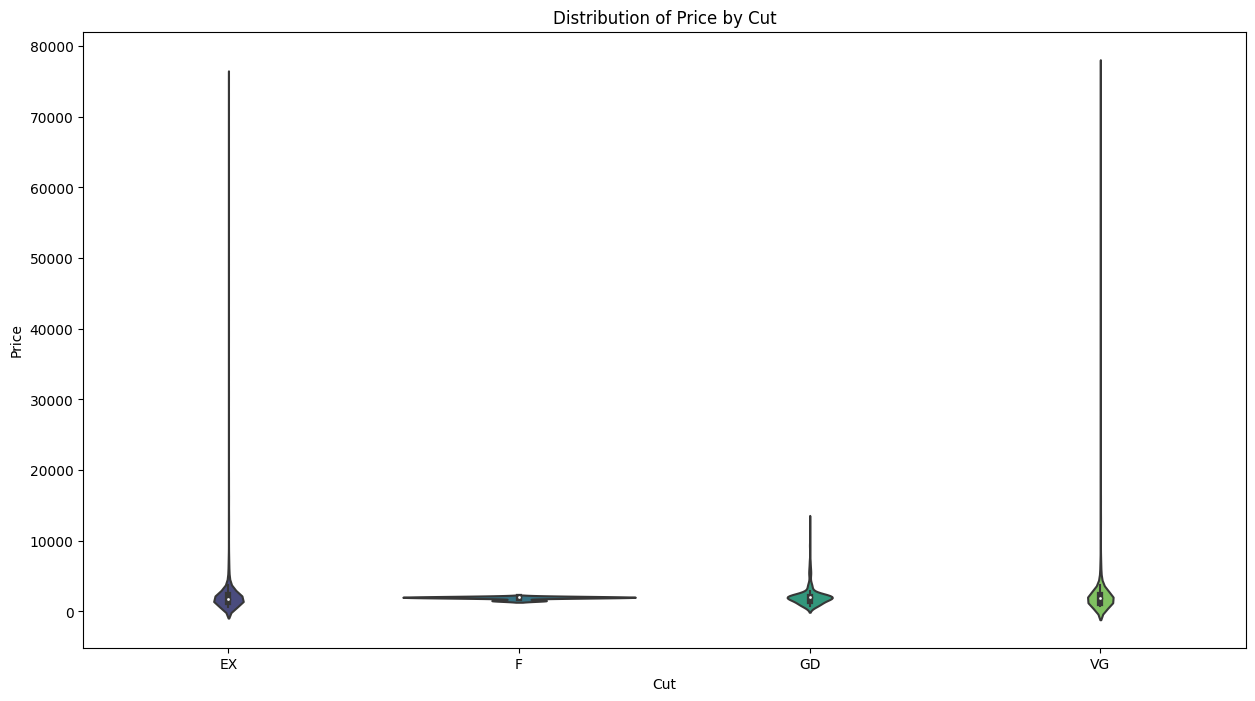

In [41]:
groupby_violinplot(df, "Cut", "Price")

Exploring the Relationship between Fluorescence and Price of Diamonds.

In [42]:
describe_categorical_grouped(df, ['Fluorescence'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Fluorescence,,,,,,,,,,,,,,,,
F,1117.0,2419.010010,3874.229004,725.320007,1292.650024,1929.079956,2235.250000,64896.070312,15009664.0,9.955873,120.974609,64170.750305,942.599976,-121.249939,3649.149963,96
M,456.0,3283.869873,6725.893066,683.219971,1402.022552,2029.030029,2610.175049,76147.679688,45237616.0,7.833022,69.900032,75464.459717,1208.152496,-410.206192,4422.403793,50
N,4141.0,2336.241455,3593.500000,746.809998,1253.760010,1790.380005,2181.550049,74875.062500,12913196.0,11.438227,172.690460,74128.252502,927.790039,-137.925049,3573.235107,367
SL,6.0,7014.430176,5250.924805,2362.830078,3151.940125,6038.985107,8250.970215,16467.890625,27572212.0,1.349412,1.912828,14105.060547,5099.030090,-4496.605011,15899.515350,1
ST,243.0,3455.865234,6710.562012,770.270020,1651.380005,2085.629883,2407.665039,64580.558594,45031628.0,6.472977,46.803879,63810.288574,756.285034,516.952454,3542.092590,31
VS,19.0,4054.015625,3881.412109,903.309998,2047.999939,2304.080078,4689.560059,15690.709961,15065358.0,2.033090,3.965441,14787.399963,2641.560120,-1914.340240,8651.900238,2
VSL,9.0,4246.291016,3723.352051,1978.020020,2072.409912,2775.229980,4115.600098,13559.940430,13863350.0,2.399228,6.051363,11581.920410,2043.190186,-992.375366,7180.385376,1


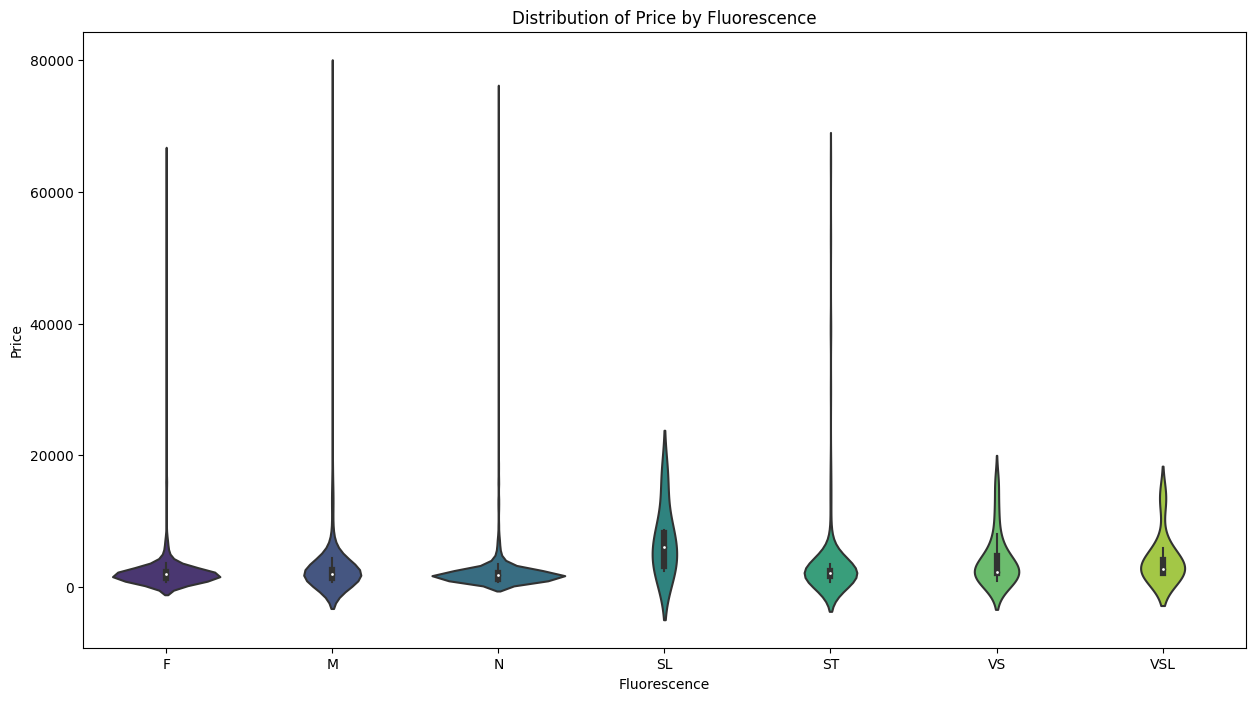

In [43]:
groupby_violinplot(df, "Fluorescence", "Price")

Exploring the Relationship between Polish and Price of Diamonds.

In [44]:
describe_categorical_grouped(df, ['Polish'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Polish,,,,,,,,,,,,,,,,
EX,4781.0,2615.883789,4455.404785,683.219971,1365.180054,1984.060059,2337.350098,76147.679688,1.985057e+07,9.741700,117.450203,75464.459717,972.170044,-93.075012,3795.605164,414
F,1.0,1539.810059,NaN,1539.810059,1539.810059,1539.810059,1539.810059,1539.810059,NaN,NaN,NaN,0.000000,0.000000,1539.810059,1539.810059,0
GD,63.0,1456.240234,1185.346313,746.809998,925.910004,1123.920044,1537.739990,9393.719727,1.405046e+06,5.203255,33.077202,8646.909729,611.829987,8.165024,2455.484970,4
VG,1146.0,1981.794678,2578.698486,753.770020,1100.132477,1520.050049,2067.182434,67616.140625,6.649682e+06,15.819429,371.818604,66862.370605,967.049957,-350.442459,3517.757370,92


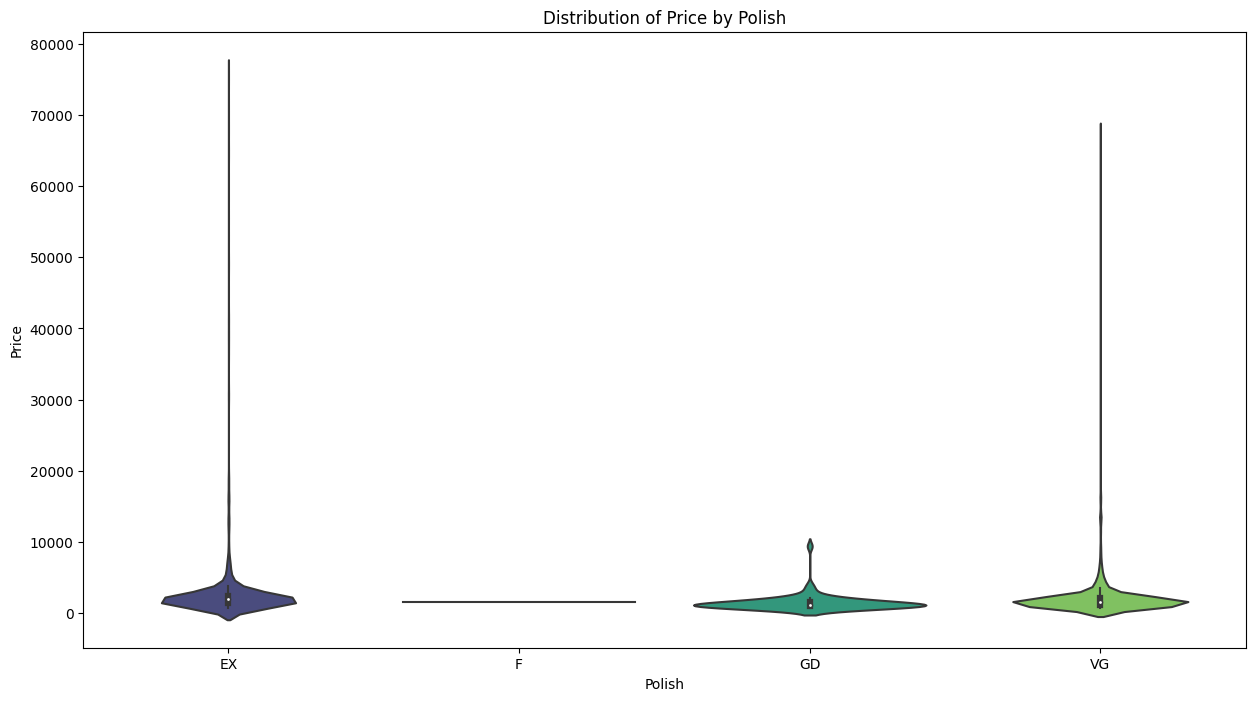

In [45]:
groupby_violinplot(df, "Polish", "Price")

Exploring the Relationship between Symmetry and Price of Diamonds.

In [46]:
describe_categorical_grouped(df, ['Symmetry'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Symmetry,,,,,,,,,,,,,,,,
EX,1698.0,3249.722900,5581.651367,794.299988,1533.969971,2062.699951,2508.744995,74875.062500,3.115485e+07,6.939526,59.034218,74080.762512,974.775024,71.807434,3970.907532,191
FR,54.0,1346.241089,426.104736,753.770020,1039.212555,1260.799988,1535.062469,2076.530029,1.815653e+05,0.559298,-0.940769,1322.760010,495.849915,295.437683,2278.837341,0
GD,1056.0,1608.405029,1388.717773,746.809998,1056.970032,1375.024963,1965.550049,38501.898438,1.928538e+06,18.518560,474.957794,37755.088440,908.580017,-305.899994,3328.420074,34
VG,3183.0,2381.953613,3810.585693,683.219971,1286.025024,1800.699951,2319.729980,76147.679688,1.452053e+07,12.805741,203.058914,75464.459717,1033.704956,-264.532410,3870.287415,248


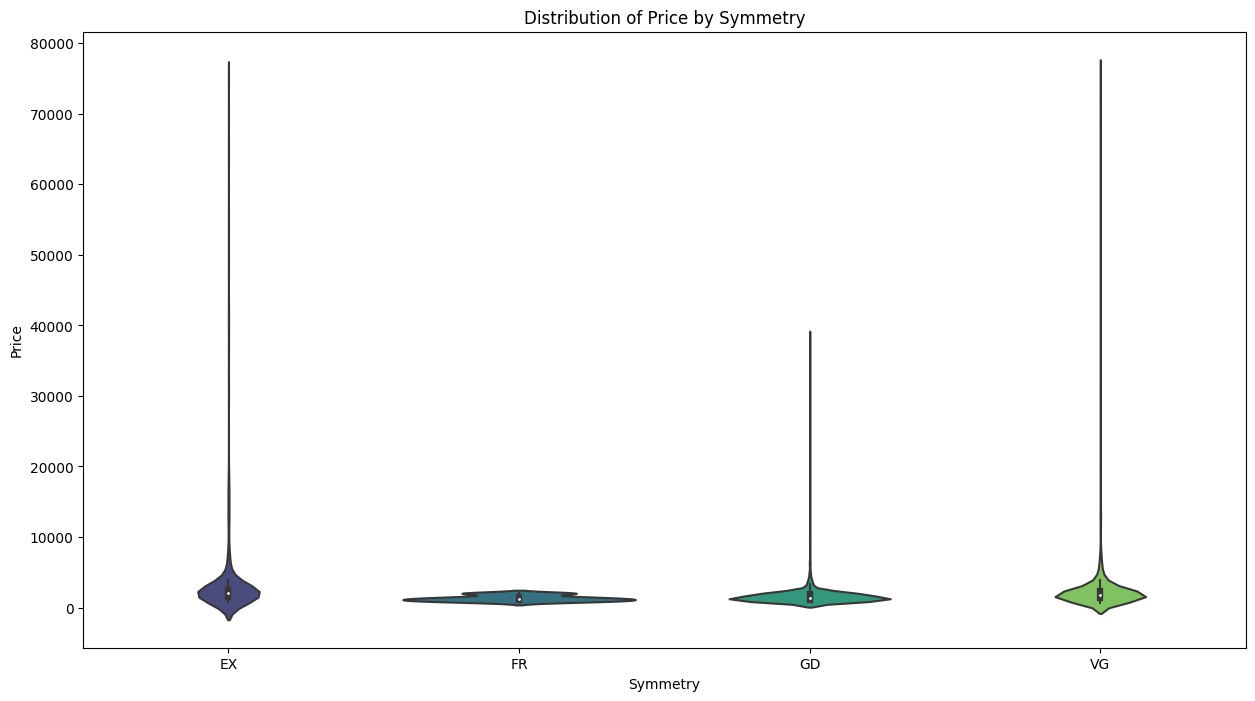

In [47]:
groupby_violinplot(df, "Symmetry", "Price")

Exploring the Relationship between Shape and Price of Diamonds.

In [48]:
describe_categorical_grouped(df, ['Shape'], 'Price')

,count,mean,std,min,25%,50%,75%,max,var,skew,kurtosis,range,IOR,lower_bound,upper_bound,outliers
Shape,,,,,,,,,,,,,,,,
CUSHION,1662.0,4017.380371,7168.291992,683.219971,1677.832489,2598.260010,3506.570068,76147.679688,5.138440e+07,6.470772,47.404873,75464.459717,1828.737579,-1065.273880,6249.676437,112
EMERALD,550.0,1202.082153,179.384720,901.799988,1058.904999,1174.674988,1289.590027,1701.949951,3.217885e+04,0.857403,0.799145,800.149963,230.685028,712.877457,1635.617569,32
HEART,345.0,999.914673,107.985573,781.640015,902.260010,1022.520020,1096.520020,1143.640015,1.166088e+04,-0.449330,-1.096719,362.000000,194.260010,610.869995,1387.910034,0
MARQUISE,68.0,1380.752563,508.952728,869.830017,1010.600006,1032.640015,1989.282501,2025.020020,2.590328e+05,0.396516,-1.845659,1155.190002,978.682495,-457.423737,3457.306244,0
OVAL,678.0,1657.793335,390.316010,764.559998,1320.517487,1735.710022,1920.712494,2374.469971,1.523468e+05,-0.310305,-0.667000,1609.909973,600.195007,420.224976,2821.005005,0
PEAR,302.0,5978.750977,4448.014648,897.690002,2283.762573,5217.695068,7145.322632,16751.619141,1.978483e+07,1.140920,0.308148,15853.929138,4861.560059,-5008.577515,14437.662720,30
PRINCESS,624.0,1406.131470,338.151489,746.809998,1069.034973,1440.000000,1705.049988,1954.959961,1.143463e+05,-0.151700,-1.178065,1208.149963,636.015015,115.012451,2659.072510,0
ROUND,1762.0,1865.536377,415.562714,826.780029,1528.704956,2041.079956,2089.610107,2568.800049,1.726921e+05,-0.855409,-0.252719,1742.020020,560.905151,687.347229,2930.967834,0


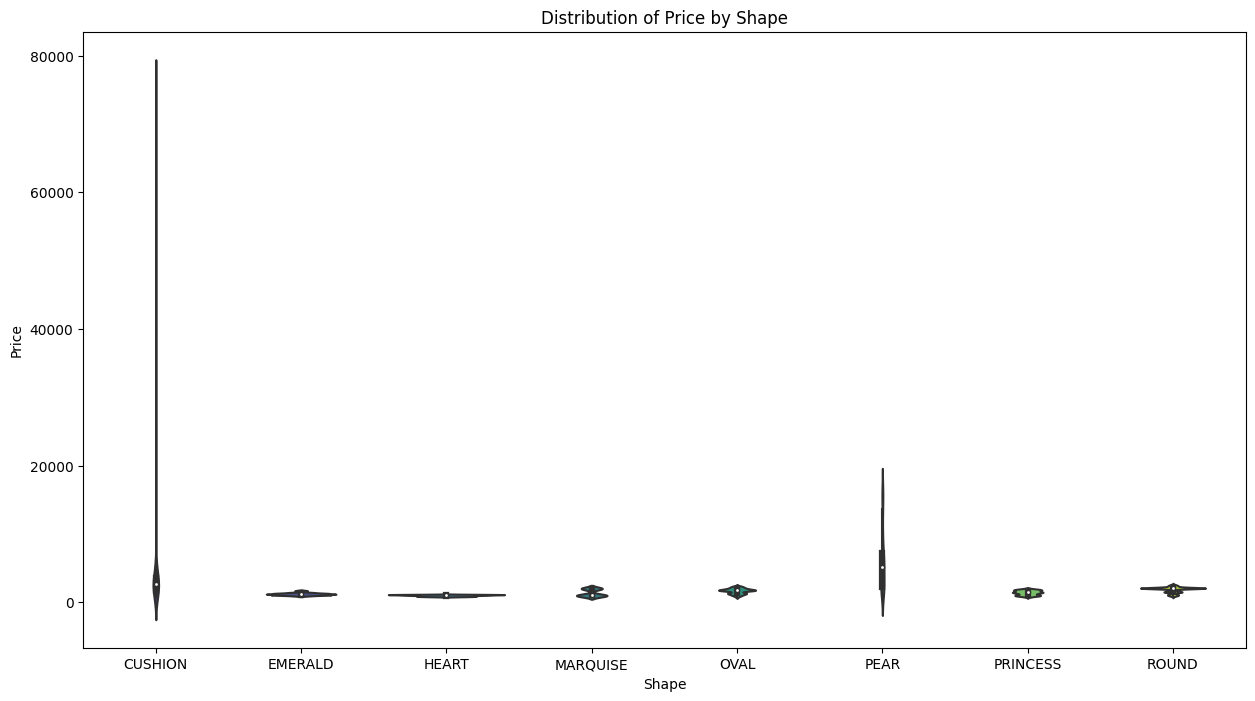

In [49]:
groupby_violinplot(df, "Shape", "Price")

## Multivalent analysis for data 📊

To visualize pairwise relationships of diamond features by shape, we can use `sns.pairplot()` function from the Seaborn library. The `hue` parameter can be used to distinguish between different shapes, and we can use a color palette such as `viridis` to differentiate the data points.

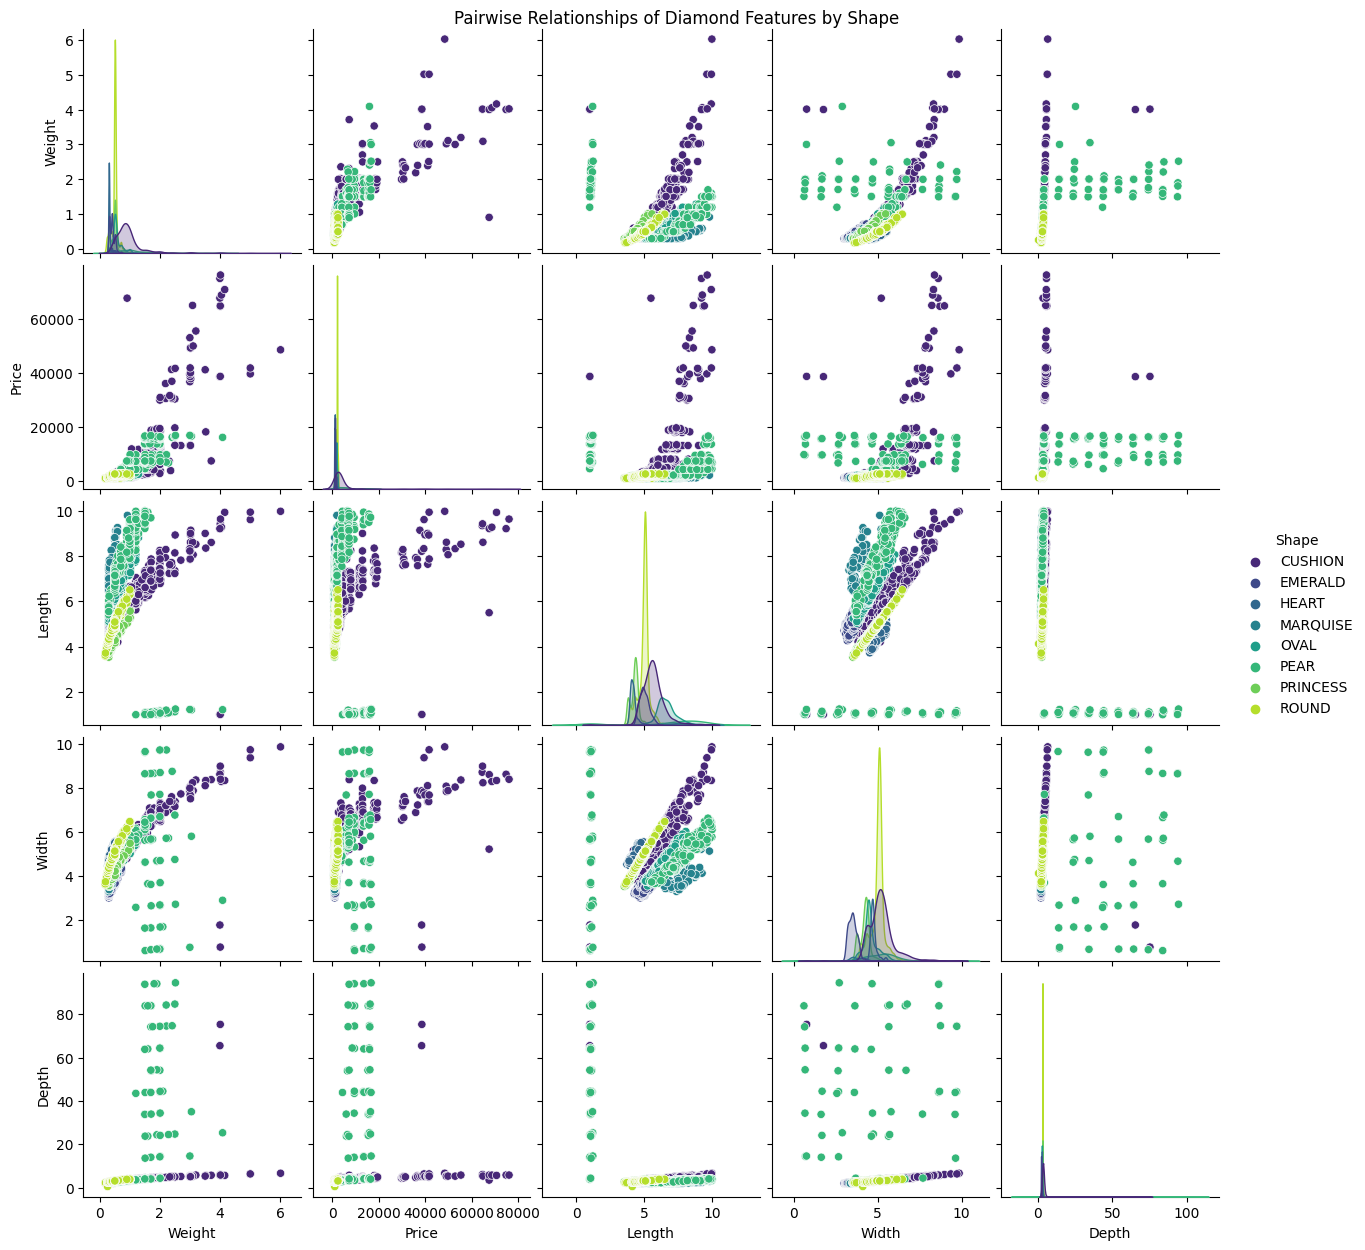

In [50]:
sns.pairplot(df, hue='Shape', palette="viridis")
plt.suptitle('Pairwise Relationships of Diamond Features by Shape', y=1)
plt.show()

**Insight 💡**

- There are a diamonds with pear shape have length less then 2 which gives use unexpected graph.
- There are some diamonds with cushion shape having price more then 20000.
- There are few diamonds having weight more then 3.
- There are very few diamonds having depth less then 1

So we what to remove this outliers

## Handling Outliers 🚫

We will apply visual inspection method to remove outliers.

So we will use jointplot to get clear picture

Relationship between Length, Price, and Shape of Diamonds

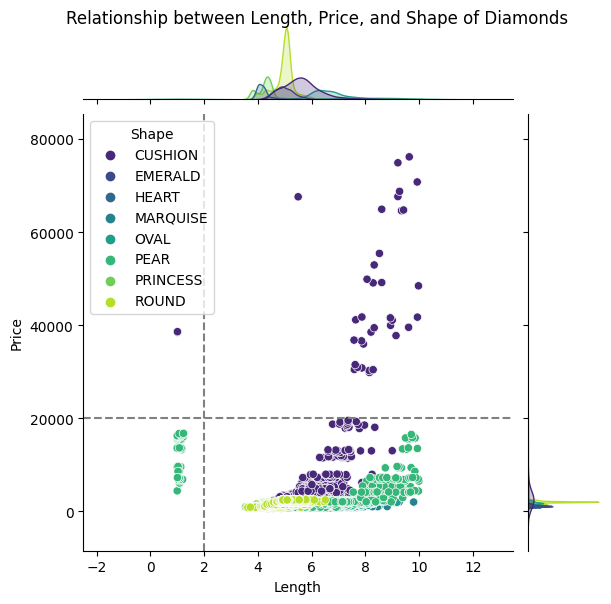

In [51]:
kdeplot = sns.jointplot(data=df, x="Length", y="Price", hue="Shape", palette="viridis")
plt.suptitle('Relationship between Length, Price, and Shape of Diamonds', y=1)
kdeplot.ax_joint.axvline(x=2,linestyle='--', color='grey')
kdeplot.ax_joint.axhline(y=20000,linestyle='--', color='grey')
plt.show()

Relationship between Length, Price, and Shape of Diamonds

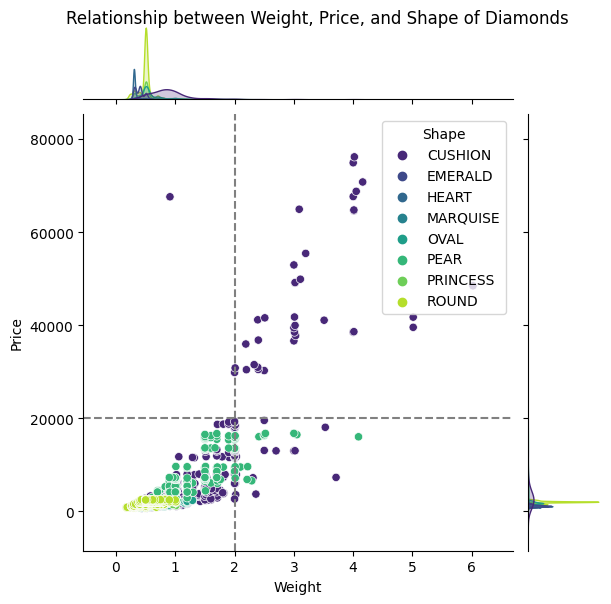

In [52]:
kdeplot = sns.jointplot(data=df, x="Weight", y="Price", hue="Shape", palette="viridis")
plt.suptitle('Relationship between Weight, Price, and Shape of Diamonds', y=1)
kdeplot.ax_joint.axvline(x=2,linestyle='--', color='grey')
kdeplot.ax_joint.axhline(y=20000,linestyle='--', color='grey')
plt.show()

Relationship between Depth, Length, and Shape of Diamonds

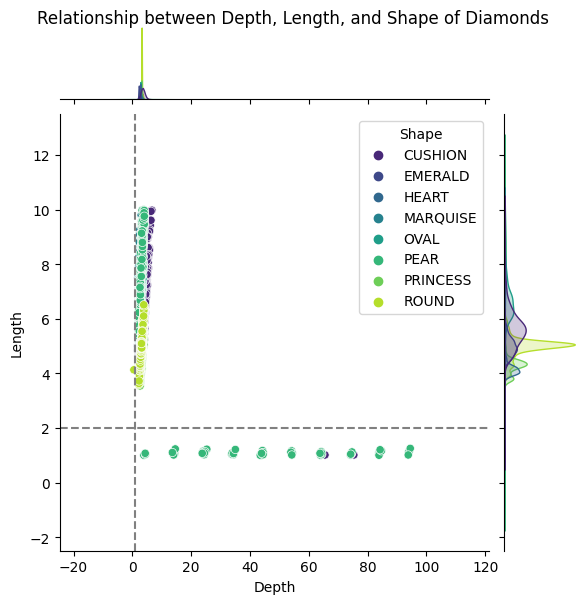

In [53]:
kdeplot = sns.jointplot(data=df, x="Depth", y="Length", hue="Shape", palette="viridis")
plt.suptitle('Relationship between Depth, Length, and Shape of Diamonds', y=1)
kdeplot.ax_joint.axvline(x=1,linestyle='--', color='grey')
kdeplot.ax_joint.axhline(y=2,linestyle='--', color='grey')
plt.show()

Selecting outliers using query method

In [54]:
df.query('Price > 20000 or Length < 2 or Weight > 3 or Depth < 1')

,Id,Shape,Weight,Clarity,Colour,Cut,Polish,Symmetry,Fluorescence,Price,Length,Width,Depth
index,,,,,,,,,,,,,
1518,210315-74,CUSHION,3.710938,SI2,FANCY,VG,EX,VG,F,7291.850098,8.601562,8.367188,5.738281
1573,200705-4,CUSHION,6.019531,VS2,FANCY,EX,EX,VG,F,48445.269531,9.976562,9.851562,6.660156
1574,200704-11,CUSHION,3.019531,VVS2,D,EX,EX,EX,M,49075.339844,8.289062,8.070312,5.468750
1575,200807-308,CUSHION,3.019531,VS2,D,EX,EX,EX,F,49149.089844,8.609375,7.828125,5.300781
1576,200705-12,CUSHION,3.109375,VVS1,FANCY,EX,EX,VG,N,49865.460938,8.062500,7.871094,5.351562
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3645,200693-57,PEAR,2.009766,SI2,J,EX,VG,VG,N,7142.750000,1.070312,3.699219,4.371094
3647,210511-24,PEAR,1.509766,SI1,L,EX,EX,EX,F,7173.990234,1.070312,4.628906,23.765625
3654,Eco Diamond LG200597,PEAR,1.500000,VS1,F,VG,EX,EX,N,7252.100098,1.009766,8.632812,93.812500


**Insight 💡**

There are 96 diamonds which are outliers

Descarding outliers and createing new datadrame called `filtered_df`

In [55]:
filtered_df = df.query('Price <= 20000 and Length >= 2 and Weight <= 3 and Depth >= 1')

Pairwise Relationships of Diamond Features by Shape using filtered_df

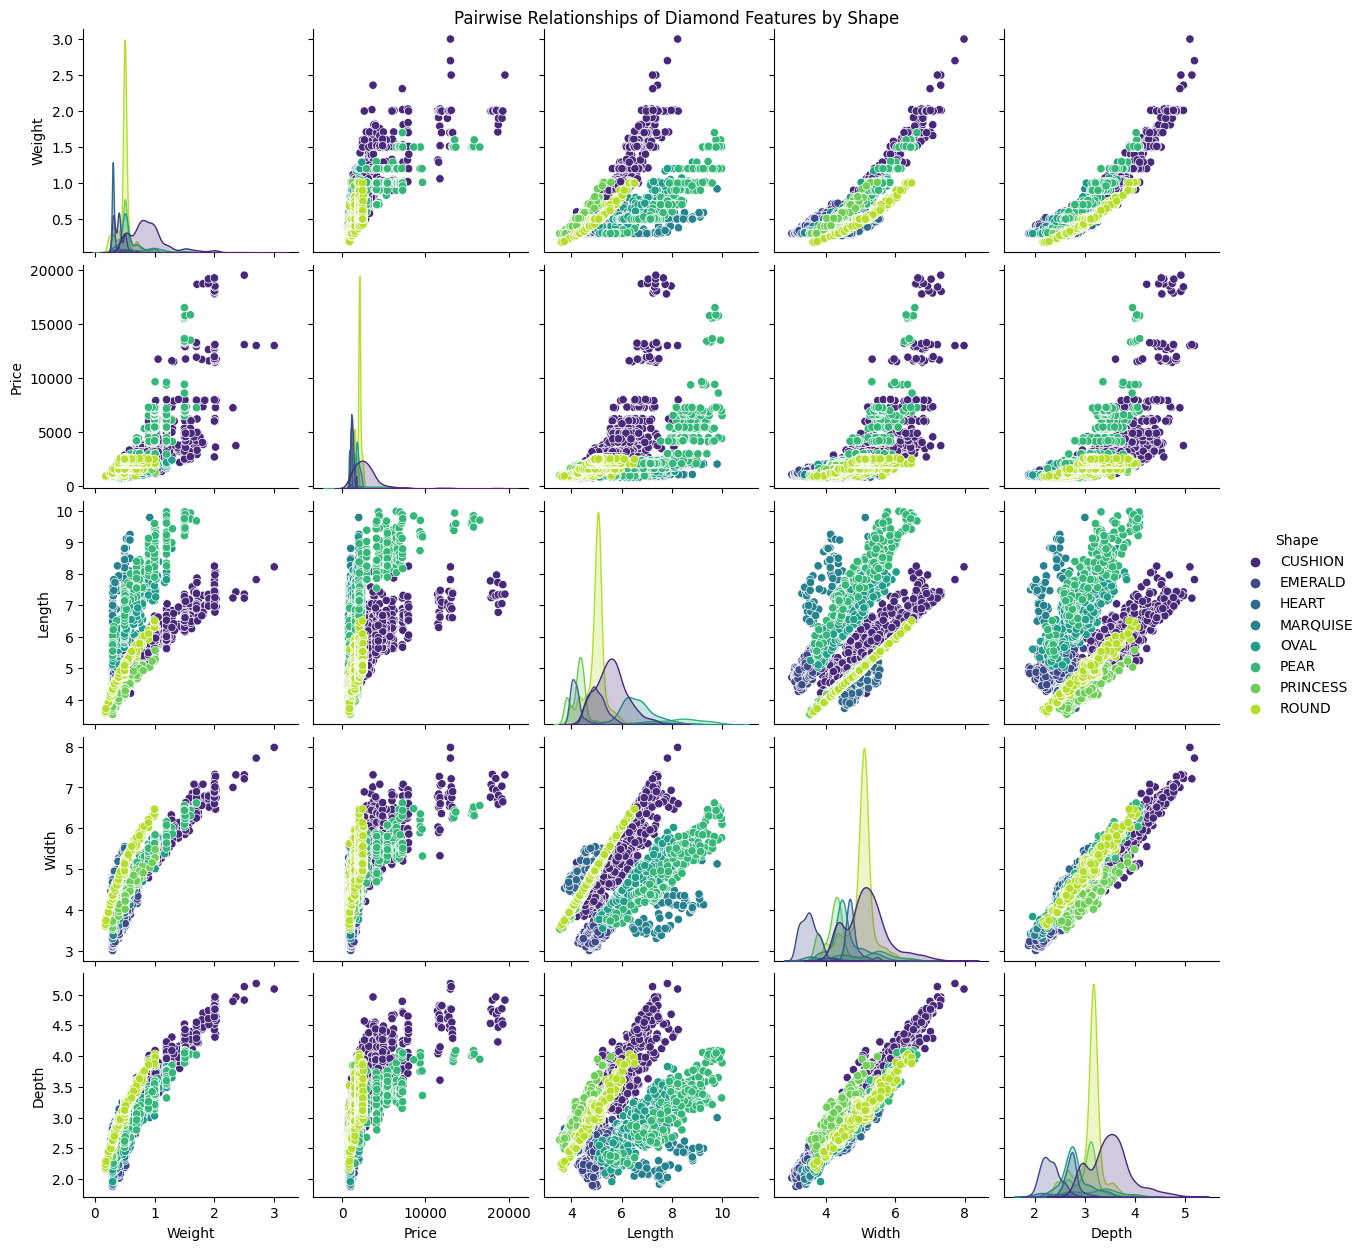

In [56]:
sns.pairplot(filtered_df, hue='Shape', palette="viridis")
plt.suptitle('Pairwise Relationships of Diamond Features by Shape', y=1)
plt.show()

Correlation Matrix of Diamond Features

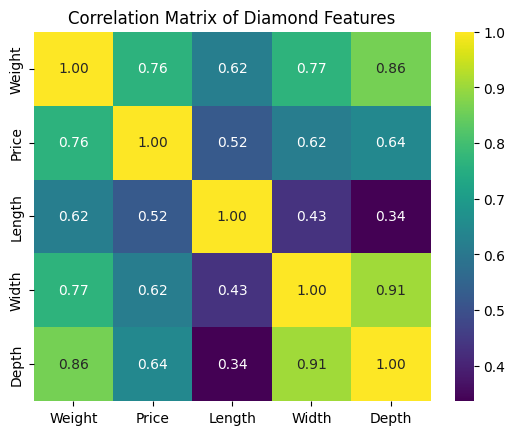

In [57]:
sns.heatmap(filtered_df.corr(numeric_only = True), annot=True, fmt=".2f", cmap="viridis")
plt.title('Correlation Matrix of Diamond Features')
plt.show()

Checking the filtered_df info

In [58]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5895 entries, 0 to 6338
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Id            5895 non-null   object  
 1   Shape         5895 non-null   category
 2   Weight        5895 non-null   float32 
 3   Clarity       5895 non-null   category
 4   Colour        5895 non-null   category
 5   Cut           5895 non-null   category
 6   Polish        5895 non-null   category
 7   Symmetry      5895 non-null   category
 8   Fluorescence  5895 non-null   category
 9   Price         5895 non-null   float32 
 10  Length        5895 non-null   float32 
 11  Width         5895 non-null   float32 
 12  Depth         5895 non-null   float32 
dtypes: category(7), float32(5), object(1)
memory usage: 249.9+ KB


## Saving the filtered dataframe 📎

Save the dataframe in `./../data/filtered_diamonds.csv` without index

In [59]:
filtered_df.to_csv("./../data/filtered_diamonds.csv", index=False)

Also saving in parquet file using BROTLI compression and this will be save at `./../data/filtered_diamonds.br`

In [60]:
filtered_df.to_parquet("./../data/filtered_diamonds.br", compression="BROTLI")

## Conclusion 🎉

In this project, we used Python to perform an exploratory data analysis (EDA) on the Diamonds dataset. We started by importing the necessary libraries and loading the data. We then performed data exploration, which involved looking at the first few rows of the dataset, checking for missing values, and getting summary statistics for the numerical data.

Next, we conducted univalent analysis for numerical and categorical data to better understand the distribution of the data. We also performed bivalent analysis for categorical data to check the relationships between different categorical variables. Additionally, we conducted multivalent analysis to analyze multiple variables at once.

After conducting the analysis, we discovered that there were some outliers in the data. To handle these outliers, we used different technique such as removing the outliers using visual inspection method. Finally, we saved the filtered dataset for further analysis.

Overall, this exploratory data analysis provides valuable insights into the Diamonds dataset, helping us to understand the relationships between different variables and identify any outliers that could impact the accuracy of our analysis.